---

# Perfiles multidimensionales de brecha tecnológica en los locales educativos del Perú: recursos, conectividad y cobertura móvil territorial

**Grupo:** Mineros

**Integrantes:**
- Delgado Santana, Francisco Luis
- Pando Cabezas, Nicole Rashel
- Rua Pomahuacre, Brayan Anderson

---

<a name='tema'></a>

### <font color="#5B9BD5">Tema</font>

**Perfiles de brecha tecnológica y conectividad digital en los locales educativos del Perú**

---

<a name='fuentes'></a>

### <font color="#5B9BD5">Fuentes</font>

**ESCALE** [Estadística de la Calidad Educativa]

- Censo Local (universo de locales): base principal del censo educativo que identifica a todos los locales educativos del Perú y sirve como marco para distinguir entre establecimientos con y sin conexión a internet.
  - [Página de descarga](https://escale.minedu.gob.pe/documents/inicio/Bases%20de%20datos/A.%20Censo%20Educativo/2025)
  - [Descarga directa](https://escale.minedu.gob.pe/documents/inicio/Bases%20de%20datos/A.%20Censo%20Educativo/2025/51_Loc_lineal_1.zip)

- Líneas de internet: base de datos que detalla las líneas reportadas por cada local educativo, incluyendo su actividad, proveedor, financiamiento y velocidades. Puede contener líneas activas e inactivas.
  - [Página de descarga](https://escale.minedu.gob.pe/documents/10156/adf8b0d0-2b5b-480f-b082-4ca962888f37)
  - [Descarga directa](https://escale.minedu.gob.pe/documents/10156/10632985/59_loc_p3230_inter.zip)

- Recursos tecnológicos (locales con y sin conexión): base de datos que registra la disponibilidad de equipos y recursos tecnológicos del establecimiento, permitiendo comparar la infraestructura entre locales conectados y no conectados.
  - [Página de descarga](https://escale.minedu.gob.pe/documents/10156/b7081fbe-f72a-45fc-8cbe-f392204eebeb)
  - [Descarga directa](https://escale.minedu.gob.pe/documents/10156/10632985/67_loc_p91_rectec.zip)

- Padlocal: Contiene la relación de locales educativos que conforman el marco censal.
  - [Página de descarga](https://escale.minedu.gob.pe/documents/10156/c6cfd793-d22a-4d8c-9f7e-93d6f344803d)
  - [Descarga directa](https://escale.minedu.gob.pe/documents/10156/10632985/00_Padlocal.zip)


**OSIPTEL** [Organismo Supervisor de Inversión Privada en Telecomunicaciones]

- Cobertura móvil: base de datos que detalla la cobertura móvil por centro poblado, empresa operadora y tecnología (2G, 3G, 4G y 5G).
  - [Dataset](https://www.datosabiertos.gob.pe/dataset/porcentaje-de-cobertura-m%C3%B3vil-por-centro-poblado-empresa-operadora-y-tecnolog%C3%ADa)

---

<a name='unidad'></a>

### <font color="#5B9BD5">Unidad de análisis</font>

Local educativo censado en 2025. La base integrada conserva los 42 221 locales que coinciden con la fuente de recursos tecnológicos; los perfiles se referirán a ese conjunto.

---

<a name='problema'></a>

### <font color="#5B9BD5">Problema</font>

En Perú, una parte importante de los locales educativos reporta acceso a internet y otra parte no, pero no se conoce cómo se diferencian estos grupos en términos de infraestructura tecnológica, cobertura territorial y disponibilidad real de servicios digitales. La principal característica que orienta este estudio es precisamente la presencia o ausencia de conexión, porque permite comparar las condiciones de conectividad junto con el equipamiento y la cobertura del entorno. Estas fuentes no miden directamente el uso de los equipos ni la calidad pedagógica. Además, es necesario saber si los locales conectados presentan también equipos funcionales y si los no conectados se encuentran en contextos de mayor desventaja o aislamiento territorial.

---

<a name='objetivo'></a>

### <font color="#5B9BD5">Objetivo</font>

Explorar, mediante clustering y detección de anomalías, los perfiles de locales educativos del Perú diferenciados por la presencia o ausencia de conexión a internet, y relacionarlos con la disponibilidad de recursos tecnológicos, la cobertura móvil y la condición territorial, para identificar grupos con mayor y menor brecha digital, así como casos atípicos con combinaciones poco habituales de equipamiento y conectividad dentro del conjunto analizado.


## **Fase 1: Inspección inicial**

In [ ]:
!pip install dbfread

"pip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


### **Sección 1: Importar librerías y cargar fuentes**

In [ ]:
# Importar librerías
from dbfread import DBF
import pandas as pd
import numpy as np
import seaborn as sns

# Ajustar tamaño de tablas
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# Cargar fuentes .dbf
servicios_internet_raw = pd.DataFrame(iter(DBF(r"Loc_p3230_inter.dbf", encoding="latin1")))
recursos_tecnologicos_raw = pd.DataFrame(iter(DBF(r"loc_p91_rectec.dbf", encoding="latin1")))
padron_raw  = pd.DataFrame(iter(DBF(r"Padlocal.dbf", encoding="latin1")))
censo_local_raw = pd.DataFrame(iter(DBF(r"loc_lineal_1.dbf", encoding="latin1")))

# Cargar fuentes .excel y concatenar
osiptel_1 = pd.read_excel(r"osiptel_cobertura_2025IV_parte1.xlsx", sheet_name="Listado", dtype={"Ubigeo": str})
osiptel_2 = pd.read_excel(r"osiptel_cobertura_2025IV_parte2.xlsx", sheet_name="Listado", dtype={"Ubigeo": str})
cobertura_movil_raw = pd.concat([osiptel_1, osiptel_2], ignore_index=True)


# Mostrar los 3 primeros registros de cada fuente
print("DATASET: servicios_internet\n")
display(servicios_internet_raw.head(3))

print("DATASET: recursos_tecnologicos\n")
display(recursos_tecnologicos_raw.head(3))

print("DATASET: padron\n")
display(padron_raw.head(3))

print("DATASET: cobertura_movil\n")
display(cobertura_movil_raw.head(3))

print("DATASET: censo_local\n")
display(censo_local_raw.head(3))

DATASET: servicios_internet



,CODLOCAL,NROCED,CUADRO,NUMERO,P3230_1,P3230_2,P3230_3,P3230_4,P3230_5,P3230_6,P3230_7,P3230_8,P3230_9,P3230_10,FEC_ENVIO,ANEXO
0,000024,11,C3230,1,LINEA 01,1,02,01,01,6.0,70.0,6,6,2,2025-09-26 15:04:52,0
1,000038,11,C3230,1,LINEA 01,1,02,09,02,1000.0,100.0,50,100,1,2025-09-25 16:38:29,0
2,000062,11,C3230,1,LINEA 01,1,02,09,03,200.0,100.0,100,200,2,2025-09-12 08:33:43,0


DATASET: recursos_tecnologicos



,CODLOCAL,NROCED,CUADRO,NUMERO,P91_1,P91_2,P91_3_1,P91_3_21,P91_3_22,P91_3_31,P91_3_32,P91_3_411,P91_3_412,P91_3_413,P91_3_4141,P91_3_4142,P91_3_421,P91_3_422,P91_3_423,P91_3_4241,P91_3_4242,P91_3_431,P91_3_432,P91_3_433,P91_3_4341,P91_3_4342,FEC_ENVIO,GESTION,ANEXO
0,000024,11,C091,1,01: PC DE ESCRITORIO,3,3,3,0,2,1,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,2025-09-26 15:04:52,1,0
1,000024,11,C091,9,09: PROYECTOR MULTIMEDIA,1,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2025-09-26 15:04:52,1,0
2,000038,11,C091,1,01: PC DE ESCRITORIO,4,4,4,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,2025-09-25 16:38:29,1,0


DATASET: padron



,CODLOCAL,DIR_CEN,LOCALIDAD,CODCP_INEI,CODCCPP,CEN_POB,CODGEO,D_DPTO,D_PROV,D_DIST,D_REGION,CODOOII,D_DREUGEL,ESTADO,D_ESTADO,CLOC_L1,AREA_LOC,GES_LOC,TIP_ENVIO
0,016100,JIRON TERESA GONZALES DE FANNY 543,NICRUPAMPA,0201050001,129688,CENTENARIO,020105,ANCASH,HUARAZ,INDEPENDENCIA,DRE ANCASH,020001,UGEL HUARAZ,1,Activo,016100,1,A,1.Respondio a FUIE
1,015172,JIRON 28 DE JULIO S/N,HUARUPAMPA,0201010001,114517,HUARUPAMPA,020101,ANCASH,HUARAZ,HUARAZ,DRE ANCASH,020001,UGEL HUARAZ,1,Activo,015172,1,A,1.Respondio a FUIE
2,015186,JIRON AMADEO FIGUEROA S/N,,,610619,LA SOLEDAD,020101,ANCASH,HUARAZ,HUARAZ,DRE ANCASH,020001,UGEL HUARAZ,1,Activo,015186,1,A,1.Respondio a FUIE


DATASET: cobertura_movil



,Ubigeo,Departamento,Provincia,Distrito,CentroPoblado,Clasificacion,LAT_Y,LON_X,Bitel_3G_CG,Bitel_3G_CG+CAR,Bitel_4G_CG,Bitel_4G_CG+CAR,Bitel_5G_CG,Bitel_5G_CG+CAR,Claro_2G_CG,Claro_2G_CG+CAR,Claro_3G_CG,Claro_3G_CG+CAR,Claro_4G_CG,Claro_4G_CG+CAR,Claro_5G_CG,Claro_5G_CG+CAR,Entel_2G_CG,Entel_2G_CG+CAR,Entel_3G_CG,Entel_3G_CG+CAR,Entel_4G_CG,Entel_4G_CG+CAR,Entel_5G_CG,Entel_5G_CG+CAR,Integratel_2G_CG,Integratel_2G_CG+CAR,Integratel_3G_CG,Integratel_3G_CG+CAR,Integratel_4G_CG,Integratel_4G_CG+CAR,Integratel_5G_CG,Integratel_5G_CG+CAR
0,0101010001,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,CHACHAPOYAS,URBANO,-6.22941,-77.87250,0.550521,0.718572,0.460655,0.944967,0.410005,0.665083,0.60817,1.0,0.370388,1.000000,0.206659,0.988613,0.0,0.0,0,0.965663,0,0.997751,0.01171,0.998219,0,0.0,0.347482,0.969168,0.840749,0.915419,0.992093,1.000000,0.0,0.0
1,0101010002,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,CACLIC,RURAL,-6.20244,-77.90147,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.0,0.000000,0.220374,0.000000,0.000000,0.0,0.0,0,1.000000,0,1.000000,0.00000,1.000000,0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.291443,0.0,0.0
2,0101010003,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,VITALIANO,RURAL,-6.20987,-77.87266,0.000000,0.000000,0.000000,0.550689,0.000000,0.000000,0.00000,1.0,0.000000,1.000000,0.000000,0.998191,0.0,0.0,0,1.000000,0,1.000000,0.00000,1.000000,0,0.0,0.000000,0.921899,0.000000,0.412609,1.000000,1.000000,0.0,0.0


DATASET: censo_local



,CODLOCAL,NROCED,CODGEO,CODUGEL,DPTO,PROV,DISTRITO,AMBITO,REDEDUCA,CEN_POB,CATEG_CP,NOMLUGAR,CATEG_LG,TIPOVIA,NOMBVIA,NUMERO,MANZANA,LOTE,SECTOR,ZONA,ETAPA,OTROS,REFERENCIA,LATITUD,LONGITUD,ALTITUD,CLIMA,P122,P211,P211_SI,P212_FI,P212_FC,P212_CUI,P213,P213_4_OT,P213_6_OT,P221,P222_1,P222_2,P222_3,P222_4,P222_5,P222_1_COD,P222_5_OT,P223,P223_7_OT,P231,P232,P234,P235,...,P3221_3,P3222,P3223,P3223_S_M,P3223_S_MF,P3224,P3224_NO_1,P3224_NO_2,P3224_NO_3,P3224_NO_4,P3224_NO_5,P3224_NO_6,P3224_NO_7,P3225,P3225_23_1,P3225_23_2,P3225_23_3,P3226,P3226_SI,P3227,P3228_COD,P3228_OPER,P3229_PRE,P3229_TEL,P3230,P3230_SI,P3230_NO_1,P3230_NO_2,P3231,P3231_SI,P3232,P3233,P3234,P3235,P3236,P3237,P3237_SI,P3238_1,P3238_2,P3238_3,P3238_4,P3238_5,P3238_6,P3238_6_OT,FEC_ENVIO,GESTION,ANEXO,AREA_LOC,GES_LOC,TIP_ENVIO
0,000019,11,010101,010001,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,UGEL,UGEL CHACHAPOYAS,CHACHAPOYAS,4,CHACHAPOYAS,05,3,JIRON JUNIN,979,,,,,,,A DOS CUADRAS DE LA PLAZA DE ARMAS,-6.23176,-77.87243,0,8,2,2,,,,,,,,3,,,,,,,,,,1,2210.00,1,2,...,,1,1,1,1,1,,,,,,,,1,,,,2,,,,,,,1,0,1,2,2,,,,,,2,2,,X,,,,,,,2025-09-15 11:02:09,1,0,1,A,1.Respondio a FUIE
1,000024,11,010101,010001,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,UGEL,UGEL CHACHAPOYAS,CHACHAPOYAS,4,----------------------------------------------...,11,3,JUNIN,697,,,,,,,AL COSTADO DE LA INSTITUCION EDUCATIVA MIGUEL ...,-6.23159,-77.87002,0,8,2,2,,,,,,,,3,,,,,,,,,,1,1133.16,2,4,...,,2,1,1,1,1,,,,,,,,1,,,,1,1,1,04,MOVISTAR,41,41260153,1,1,,,2,,,,,,1,1,2,X,,,,,,,2025-09-26 15:04:52,1,0,1,A,1.Respondio a FUIE
2,000038,11,010101,010001,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,UGEL,UGEL CHACHAPOYAS,CHACHAPOYAS,4,LUYA URCO,03,3,PUNO 261,1,,,,,,,A UNA CUADRA ANTES DEL ASCILO DE ANCIANOS,-6.22700,-77.87552,0,7,2,2,,,,,,,,3,,,,,,,,,,1,620.00,1,2,...,,1,1,1,1,1,,,,,,,,1,,,,2,,,,,,,1,1,,,2,,,,,,1,2,,X,,,,,,,2025-09-25 16:38:29,1,0,1,A,1.Respondio a FUIE


### **Sección 2: Selección de columnas a trabajar**

Seleccionamos las columnas relevantes para responder a la pregunta de investigación y descartamos aquellas que no aportan información relacionada con nuestro tema de estudio.

In [ ]:
servicios_internet = servicios_internet_raw.drop(columns=["NROCED", "CUADRO", "ANEXO"])
recursos_tecnologicos  = recursos_tecnologicos_raw.drop(columns=["NROCED", "CUADRO","GESTION", "ANEXO",'P91_3_411',
       'P91_3_412', 'P91_3_413', 'P91_3_4141', 'P91_3_4142', 'P91_3_421',
       'P91_3_422', 'P91_3_423', 'P91_3_4241', 'P91_3_4242', 'P91_3_431',
       'P91_3_432', 'P91_3_433', 'P91_3_4341', 'P91_3_4342'])
padron  = padron_raw.drop(columns=['CLOC_L1',"TIP_ENVIO"])
cobertura_movil = cobertura_movil_raw.drop(columns= [
       'Departamento', 'Provincia', 'Distrito', 'CentroPoblado',
       'Bitel_3G_CG+CAR', 'Bitel_4G_CG+CAR', 'Bitel_5G_CG+CAR',
       'Claro_2G_CG+CAR', 'Claro_3G_CG+CAR', 'Claro_4G_CG+CAR',
       'Claro_5G_CG+CAR', 'Entel_2G_CG+CAR', 'Entel_3G_CG+CAR',
       'Entel_4G_CG+CAR', 'Entel_5G_CG+CAR', 'Integratel_2G_CG+CAR',
       'Integratel_3G_CG+CAR', 'Integratel_4G_CG+CAR', 'Integratel_5G_CG+CAR'])
censo_local = censo_local_raw[["CODLOCAL", "DPTO", "CEN_POB", "LATITUD", "LONGITUD", "P311_5", "P3230", "P3230_SI"]].copy()

##### **Decisiones:**

* `Servicios_internet:` Se eliminan **NROCED**, **CUADRO** y **ANEXO**, y se conservan los campos que describen las líneas y su registro.
* `Recursos_tecnologicos:` Se eliminan **NROCED**, **CUADRO**, **GESTION** y **ANEXO**, además de las 15 columnas del bloque **P91_3_411 a P91_3_4342**. Se trabaja con los totales, el estado, la antigüedad y el tipo de recurso, sin el desglose por ambiente.
* `Padron:` Se eliminan **CLOC_L1** y **TIP_ENVIO**. Más adelante se seleccionan seis campos para la integración: código del local, distrito, centro poblado MINEDU, departamento, provincia y nombre del distrito.
* `Cobertura_movil:` Se conservan las columnas de cobertura garantizada **CG** y se excluyen las **CG+CAR**. También se retiran los nombres geográficos, ya que la unión se realiza mediante códigos. No se calcula una correlación entre CG y CG+CAR en este cuaderno.
* `Censo_local:` Se conservan ocho campos: código del local, región, centro poblado, coordenadas, acceso a internet del centro poblado y del local, y cantidad de líneas declaradas.


| Dataset | Columnas seleccionadas o eliminadas | Motivo |
|---|---|---|
| Servicios_internet | Se eliminan NROCED, CUADRO y ANEXO | Se conservan los atributos de las líneas |
| Recursos_tecnologicos | Se eliminan NROCED, CUADRO, GESTION, ANEXO y las 15 columnas P91_3_4xx | Se usan los totales y condiciones del equipamiento, sin el desglose por ambiente |
| Padron | Se eliminan CLOC_L1 y TIP_ENVIO | Se conserva la identificación y ubicación del local |
| Cobertura_movil | Se eliminan nombres geográficos y columnas CG+CAR | Se trabaja con cobertura garantizada y códigos territoriales |
| Censo_local | Se seleccionan ocho campos | Identificación, ubicación y conectividad del local |


In [ ]:
# Columnas finales de cada fuente

print("servicios_internet:")
display(servicios_internet.columns.to_list())
print("\n")

print("recursos_tecnologicos:")
display(recursos_tecnologicos.columns.to_list())
print("\n")

print("padron:")
display(padron.columns.to_list())
print("\n")

print("cobertura_movil:")
display(cobertura_movil.columns.to_list())

print("censo_local")
display(censo_local.columns.to_list())

servicios_internet:


['CODLOCAL',
 'NUMERO',
 'P3230_1',
 'P3230_2',
 'P3230_3',
 'P3230_4',
 'P3230_5',
 'P3230_6',
 'P3230_7',
 'P3230_8',
 'P3230_9',
 'P3230_10',
 'FEC_ENVIO']



recursos_tecnologicos:


['CODLOCAL',
 'NUMERO',
 'P91_1',
 'P91_2',
 'P91_3_1',
 'P91_3_21',
 'P91_3_22',
 'P91_3_31',
 'P91_3_32',
 'FEC_ENVIO']



padron:


['CODLOCAL',
 'DIR_CEN',
 'LOCALIDAD',
 'CODCP_INEI',
 'CODCCPP',
 'CEN_POB',
 'CODGEO',
 'D_DPTO',
 'D_PROV',
 'D_DIST',
 'D_REGION',
 'CODOOII',
 'D_DREUGEL',
 'ESTADO',
 'D_ESTADO',
 'AREA_LOC',
 'GES_LOC']



cobertura_movil:


['Ubigeo',
 'Clasificacion',
 'LAT_Y',
 'LON_X',
 'Bitel_3G_CG',
 'Bitel_4G_CG',
 'Bitel_5G_CG',
 'Claro_2G_CG',
 'Claro_3G_CG',
 'Claro_4G_CG',
 'Claro_5G_CG',
 'Entel_2G_CG',
 'Entel_3G_CG',
 'Entel_4G_CG',
 'Entel_5G_CG',
 'Integratel_2G_CG',
 'Integratel_3G_CG',
 'Integratel_4G_CG',
 'Integratel_5G_CG']

censo_local


['CODLOCAL',
 'DPTO',
 'CEN_POB',
 'LATITUD',
 'LONGITUD',
 'P311_5',
 'P3230',
 'P3230_SI']

### **Sección 3: Cambiar nombres a columnas de cada Fuente**

Se renombran las columnas para facilitar la comprensión de las variables durante todo el proceso de EDA.

##### **Servicios_Internet**

In [ ]:
servicios_internet = servicios_internet.rename(columns= {
'CODLOCAL': "cod_local",
'NUMERO': "num_orden",
'P3230_1': "num_linea",
'P3230_2': "linea_activa",
'P3230_3': "tipo_conexion",
'P3230_4': "proveedor",
'P3230_5': "entidad_financia",
'P3230_6': "ancho_banda",
'P3230_7': "velocidad_garantizada_pct",
'P3230_8': "velocidad_bajada",
'P3230_9': "velocidad_subida",
'P3230_10': "filtro_contenido",
'FEC_ENVIO': "fecha_envio"
})
servicios_internet.columns

Index(['cod_local', 'num_orden', 'num_linea', 'linea_activa', 'tipo_conexion',
       'proveedor', 'entidad_financia', 'ancho_banda',
       'velocidad_garantizada_pct', 'velocidad_bajada', 'velocidad_subida',
       'filtro_contenido', 'fecha_envio'],
      dtype='object')

##### **recursos_tecnologicos**

In [ ]:
recursos_tecnologicos = recursos_tecnologicos.rename( columns = {
    'CODLOCAL': "cod_local",
    'NUMERO': "num_orden",
    'P91_1': "tipo_recurso",
    'P91_2': "cant_total",
    'P91_3_1': "cant_operativos",
    'P91_3_21': "cant_buen_estado",
    'P91_3_22': "cant_necesita_reparacion",
    'P91_3_31': "cant_antig_menos_3anios",
    'P91_3_32': "cant_antig_mas_3anios",
    'FEC_ENVIO': "fecha_envio"
})

recursos_tecnologicos.columns

Index(['cod_local', 'num_orden', 'tipo_recurso', 'cant_total',
       'cant_operativos', 'cant_buen_estado', 'cant_necesita_reparacion',
       'cant_antig_menos_3anios', 'cant_antig_mas_3anios', 'fecha_envio'],
      dtype='object')

##### **padron**

In [ ]:
padron = padron.rename( columns = {
    "CODLOCAL": "cod_local",
    "LOCALIDAD": "localidad",
    "CODCP_INEI": "cod_centro_poblado",
    "CODCCPP": "cod_ccpp_minedu",
    "CEN_POB": "centro_poblado",
    "DIR_CEN": "direccion",
    "CODGEO": "cod_distrito",
    "D_DPTO": "departamento",
    "D_PROV": "provincia",
    "D_DIST": "distrito",
    "D_REGION": "region_dre",
    "CODOOII": "cod_ugel",
    "D_DREUGEL": "nombre_ugel",
    "ESTADO": "estado_codigo",
    "D_ESTADO": "estado",
    "AREA_LOC": "area_codigo",
    "GES_LOC": "gestion_codigo"
})

padron.columns

Index(['cod_local', 'direccion', 'localidad', 'cod_centro_poblado',
       'cod_ccpp_minedu', 'centro_poblado', 'cod_distrito', 'departamento',
       'provincia', 'distrito', 'region_dre', 'cod_ugel', 'nombre_ugel',
       'estado_codigo', 'estado', 'area_codigo', 'gestion_codigo'],
      dtype='object')

##### **censo_local**

In [ ]:
censo_local = censo_local.rename(columns={
    "CODLOCAL": "cod_local",
    "DPTO": "region",
    "CEN_POB": "centro_poblado",
    "LATITUD": "latitud",
    "LONGITUD": "longitud",
    "P311_5": "centro_poblado_tiene_internet",
    "P3230": "local_educativo_tiene_internet",
    "P3230_SI": "cantidad_lineas_internet"
})

censo_local.columns

Index(['cod_local', 'region', 'centro_poblado', 'latitud', 'longitud',
       'centro_poblado_tiene_internet', 'local_educativo_tiene_internet',
       'cantidad_lineas_internet'],
      dtype='object')

### **Sección 4: Verificar tamaños**

In [ ]:
print("Tamaño de servicios_internet\n",servicios_internet.shape)
print("\n")
print("Tamaño de recursos_tecnologicos\n",recursos_tecnologicos.shape)
print("\n")
print("Tamaño de padlocal\n",padron.shape)
print("\n")
print("Tamaño de cobertura_movil\n",cobertura_movil.shape)
print("\n")
print("Tamaño de censo_local\n",censo_local.shape)

Tamaño de servicios_internet
 (28752, 13)


Tamaño de recursos_tecnologicos
 (126460, 10)


Tamaño de padlocal
 (69642, 17)


Tamaño de cobertura_movil
 (108115, 19)


Tamaño de censo_local
 (67145, 8)


### **Sección 5: Tipos detectados**

In [ ]:
print("Tipos detectados en servicios_internet:")
display(servicios_internet.dtypes)

print("Tipos detectados en recursos_tecnologicos:")
display(recursos_tecnologicos.dtypes)

print("Tipos detectados en padron:")
display(padron.dtypes)

print("Tipos detectados en cobertura_movil:")
display(cobertura_movil.dtypes)

print("Tipos detectados en censo_local:")
display(censo_local.dtypes)

Tipos detectados en servicios_internet:


cod_local                     object
num_orden                     object
num_linea                     object
linea_activa                  object
tipo_conexion                 object
proveedor                     object
entidad_financia              object
ancho_banda                  float64
velocidad_garantizada_pct    float64
velocidad_bajada               int64
velocidad_subida               int64
filtro_contenido              object
fecha_envio                   object
dtype: object

Tipos detectados en recursos_tecnologicos:


cod_local                   object
num_orden                   object
tipo_recurso                object
cant_total                   int64
cant_operativos              int64
cant_buen_estado             int64
cant_necesita_reparacion     int64
cant_antig_menos_3anios      int64
cant_antig_mas_3anios        int64
fecha_envio                 object
dtype: object

Tipos detectados en padron:


cod_local             object
direccion             object
localidad             object
cod_centro_poblado    object
cod_ccpp_minedu       object
centro_poblado        object
cod_distrito          object
departamento          object
provincia             object
distrito              object
region_dre            object
cod_ugel              object
nombre_ugel           object
estado_codigo         object
estado                object
area_codigo           object
gestion_codigo        object
dtype: object

Tipos detectados en cobertura_movil:


Ubigeo               object
Clasificacion        object
LAT_Y               float64
LON_X               float64
Bitel_3G_CG         float64
Bitel_4G_CG         float64
Bitel_5G_CG         float64
Claro_2G_CG         float64
Claro_3G_CG         float64
Claro_4G_CG         float64
Claro_5G_CG         float64
Entel_2G_CG           int64
Entel_3G_CG           int64
Entel_4G_CG         float64
Entel_5G_CG           int64
Integratel_2G_CG    float64
Integratel_3G_CG    float64
Integratel_4G_CG    float64
Integratel_5G_CG    float64
dtype: object

Tipos detectados en censo_local:


cod_local                          object
region                             object
centro_poblado                     object
latitud                           float64
longitud                          float64
centro_poblado_tiene_internet      object
local_educativo_tiene_internet     object
cantidad_lineas_internet            int64
dtype: object

Las velocidades de bajada y subida se cargan como enteros y las fechas como texto. Se convierten las velocidades a `float` y las fechas a formato de fecha. En cobertura móvil se convierten a `float` las columnas `Entel_2G_CG`, `Entel_3G_CG` y `Entel_5G_CG`.

**Decisión:** Se uniforman esos tipos para facilitar su tratamiento. Que una velocidad se haya cargado como entero no implica que su valor esté mal; la conversión tampoco recupera decimales que no estén registrados.


| Fuente | Conversión aplicada |
|---|---|
| Servicios_internet | `velocidad_bajada` y `velocidad_subida` a `float`; `fecha_envio` a fecha |
| Recursos_tecnologicos | `fecha_envio` a fecha |
| Cobertura_movil | `Entel_2G_CG`, `Entel_3G_CG` y `Entel_5G_CG` a `float` |


### **Sección 6: Número y porcentaje de faltantes**

##### **Servicios_Internet**

In [ ]:
# Número de faltantes

faltantes_servicios_internet = pd.DataFrame({
    'nro_faltantes': servicios_internet.isnull().sum(),
    'porcentaje': (servicios_internet.isnull().mean() * 100).round(2)
})
faltantes_servicios_internet


,nro_faltantes,porcentaje
cod_local,0,0.00
num_orden,0,0.00
num_linea,0,0.00
linea_activa,0,0.00
tipo_conexion,0,0.00
proveedor,0,0.00
entidad_financia,0,0.00
ancho_banda,2521,8.77
velocidad_garantizada_pct,2521,8.77
velocidad_bajada,0,0.00


##### **Recursos_tecnologicos**

In [ ]:
faltantes_recursos_tecnologicos = pd.DataFrame({
    'nro_faltantes':recursos_tecnologicos.isnull().sum(),
    'porcentaje':(recursos_tecnologicos.isnull().mean() * 100).round(2)
})

faltantes_recursos_tecnologicos

,nro_faltantes,porcentaje
cod_local,0,0.0
num_orden,0,0.0
tipo_recurso,0,0.0
cant_total,0,0.0
cant_operativos,0,0.0
cant_buen_estado,0,0.0
cant_necesita_reparacion,0,0.0
cant_antig_menos_3anios,0,0.0
cant_antig_mas_3anios,0,0.0
fecha_envio,0,0.0


##### **Padron**

In [ ]:
faltantes_padron = pd.DataFrame({
    'nro_faltantes':padron.isnull().sum(),
    'porcentaje':(padron.isnull().mean() * 100).round(2)
})

faltantes_padron

,nro_faltantes,porcentaje
cod_local,0,0.0
direccion,0,0.0
localidad,0,0.0
cod_centro_poblado,0,0.0
cod_ccpp_minedu,0,0.0
centro_poblado,0,0.0
cod_distrito,0,0.0
departamento,0,0.0
provincia,0,0.0
distrito,0,0.0


##### **cobertura_movil**

In [ ]:
faltantes_cobertura_movil = pd.DataFrame({
    'nro_faltantes':cobertura_movil.isnull().sum(),
    "porcentaje":(cobertura_movil.isnull().mean() * 100).round(2)
})

faltantes_cobertura_movil

,nro_faltantes,porcentaje
Ubigeo,0,0.0
Clasificacion,0,0.0
LAT_Y,0,0.0
LON_X,0,0.0
Bitel_3G_CG,0,0.0
Bitel_4G_CG,0,0.0
Bitel_5G_CG,0,0.0
Claro_2G_CG,0,0.0
Claro_3G_CG,0,0.0
Claro_4G_CG,0,0.0


##### **censo_local**

In [ ]:
faltantes_censo_local = pd.DataFrame({
    'nro_faltantes':censo_local.isnull().sum(),
    "porcentaje":(censo_local.isnull().mean() * 100).round(2)
})

faltantes_censo_local

,nro_faltantes,porcentaje
cod_local,0,0.0
region,0,0.0
centro_poblado,0,0.0
latitud,0,0.0
longitud,0,0.0
centro_poblado_tiene_internet,0,0.0
local_educativo_tiene_internet,0,0.0
cantidad_lineas_internet,0,0.0


Se observa que la fuente Servicios_internet presenta dos columnas con valores faltantes: "ancho_banda" y "velocidad_garantizada_pct". Ambas cuentan con 2 521 valores faltantes, lo que representa el 8.77 % del total de registros de cada columna.

**Decisión:** Se mantienen ambas columnas, debido a que contienen información relevante para el análisis de la conectividad. Al representar los valores faltantes menos del 10 % de los registros, no se considera necesario eliminar las columnas. Posteriormente, se evaluará la distribución y el significado de los valores faltantes para determinar el tratamiento más adecuado.


| **Observación** | **Decisión** |
| :--- | :--- |
| **"ancho_banda"** y **"velocidad_garantizada_pct"** presentan 2 521 valores faltantes cada una.<br>Representan el **8.77 %** de los registros. | Se mantienen por su relevancia para el análisis.<br>Posteriormente, se evaluará el tratamiento de los valores faltantes. |


### **Sección 7: Cantidad de categorías por variable**

In [ ]:
# servicios_internet
print("Servicios de internet:")
print("Cantidad de categorías por variable")
print("Tamaño: ",servicios_internet.shape)
display(servicios_internet.nunique().to_frame().rename(columns={0:"Cant_Categorías"}))
print("\n")

# recursos_tecnologicos
print("Recursos tecnológicos:")
print("Cantidad de categorías por variable")
print("Tamaño: ",recursos_tecnologicos.shape)
display(recursos_tecnologicos.nunique().to_frame().rename(columns={0:"Cant_Categorías"}))
print("\n")

# padron
print("Padron:")
print("Cantidad de categorías por variable")
print("Tamaño: ",padron.shape)
display(padron.nunique().to_frame().rename(columns={0:"Cant_Categorías"}))
print("\n")

# cobertura_movil
print("Cobertura movil:")
print("Cantidad de categorías por variable")
print("Tamaño: ",cobertura_movil.shape)
display(cobertura_movil.nunique().to_frame().rename(columns={0:"Cant_Categorías"}))
print("\n")

# censo_local
print("Censo_local:")
print("Cantidad de categorías por variable")
print("Tamaño: ",censo_local.shape)
display(censo_local.nunique().to_frame().rename(columns={0:"Cant_Categorías"}))
print("\n")

Servicios de internet:
Cantidad de categorías por variable
Tamaño:  (28752, 13)


,Cant_Categorías
cod_local,24753
num_orden,4
num_linea,4
linea_activa,2
tipo_conexion,11
proveedor,11
entidad_financia,13
ancho_banda,346
velocidad_garantizada_pct,97
velocidad_bajada,647




Recursos tecnológicos:
Cantidad de categorías por variable
Tamaño:  (126460, 10)


,Cant_Categorías
cod_local,42221
num_orden,13
tipo_recurso,174
cant_total,576
cant_operativos,539
cant_buen_estado,486
cant_necesita_reparacion,247
cant_antig_menos_3anios,398
cant_antig_mas_3anios,433
fecha_envio,41814




Padron:
Cantidad de categorías por variable
Tamaño:  (69642, 17)


,Cant_Categorías
cod_local,69642
direccion,46678
localidad,10419
cod_centro_poblado,26536
cod_ccpp_minedu,30425
centro_poblado,21598
cod_distrito,1891
departamento,25
provincia,196
distrito,1735




Cobertura movil:
Cantidad de categorías por variable
Tamaño:  (108115, 19)


,Cant_Categorías
Ubigeo,108115
Clasificacion,2
LAT_Y,102853
LON_X,102188
Bitel_3G_CG,16913
Bitel_4G_CG,10583
Bitel_5G_CG,245
Claro_2G_CG,9411
Claro_3G_CG,3400
Claro_4G_CG,2644




Censo_local:
Cantidad de categorías por variable
Tamaño:  (67145, 8)


,Cant_Categorías
cod_local,67145
region,26
centro_poblado,27349
latitud,63957
longitud,63736
centro_poblado_tiene_internet,3
local_educativo_tiene_internet,3
cantidad_lineas_internet,5


Se observan códigos vacíos, guiones y variantes de texto que aumentan el número de categorías. En recursos también aparecen descripciones específicas dentro de «13: OTROS».

**Decisión:** Se revisan las frecuencias antes de recodificar. Más adelante se convierten los vacíos tratados en faltantes y se agrupan los tipos de recursos y financiamiento. Tener más valores distintos no demuestra por sí solo que sean categorías inválidas.


| Observación | Decisión |
|---|---|
| Hay códigos vacíos, guiones y variantes de texto | Revisar las frecuencias y estandarizar antes de crear indicadores |


### **Sección 8: Detectar categorías mal escritas**

##### **servicios_internet**

In [ ]:
print("tipo_conexion")
display(servicios_internet["tipo_conexion"].value_counts(dropna=False).to_frame().rename(columns={"count":"Cantidad"}).reset_index())
print("\n")

print("proveedor")
display(servicios_internet["proveedor"].value_counts(dropna=False).to_frame().rename(columns={"count":"Cantidad"}).reset_index())
print("\n")

print("entidad_financia")
display(servicios_internet["entidad_financia"].value_counts(dropna=False).to_frame().rename(columns={"count":"Cantidad"}).reset_index())
print("\n")

print("filtro_contenido")
display(servicios_internet["filtro_contenido"].value_counts(dropna=False).to_frame().rename(columns={"count":"Cantidad"}).reset_index())
print("\n")


tipo_conexion


,tipo_conexion,Cantidad
0,02,12845
1,05,3321
2,01,3292
3,06,3194
4,04,1800
5,09,1513
6,03,853
7,07,748
8,,598
9,08,538




proveedor


,proveedor,Cantidad
0,09,8817
1,01,7156
2,04,4090
3,02,4072
4,07,1658
5,05,1060
6,08,840
7,,598
8,03,424
9,06,35




entidad_financia


,entidad_financia,Cantidad
0,07,9781
1,01,8628
2,11,2386
3,02,2356
4,10,1802
5,08,1074
6,03,749
7,,598
8,05,530
9,09,511




filtro_contenido


,filtro_contenido,Cantidad
0,1,15624
1,2,10015
2,-,2521
3,,592


##### **recursos_tecnologicos**

In [ ]:
print("tipo_recurso")
display(recursos_tecnologicos["tipo_recurso"].value_counts(dropna=False).to_frame().rename(columns={"count":"Cantidad"}).reset_index())
print("\n")

tipo_recurso


,tipo_recurso,Cantidad
0,01: PC DE ESCRITORIO,29062
1,09: PROYECTOR MULTIMEDIA,24746
2,02: LAPTOP CONVENCIONAL,21962
3,06: TABLET - APRENDO EN CASA,17067
4,03: LAPTOP XO,13535
...,...,...
169,13: OTROS EQUIPO DE SONIDO PEQUE¤O,1
170,13: OTROS ALL IN ONE,1
171,13: OTROS AURICULARES SIN MICROFONO,1
172,13: OTROS CROOMEBOOK,1


##### **padron**

In [ ]:
print("departamento")
display(padron["departamento"].value_counts(dropna=False).to_frame().rename(columns={"count":"Cantidad"}).reset_index())
print("\n")

print("provincia")
display(padron["provincia"].value_counts(dropna=False).to_frame().rename(columns={"count":"Cantidad"}).reset_index())
print("\n")

print("distrito")
display(padron["distrito"].value_counts(dropna=False).to_frame().rename(columns={"count":"Cantidad"}).reset_index())
print("\n")

departamento


,departamento,Cantidad
0,LIMA,9627
1,CAJAMARCA,6803
2,PUNO,4418
3,PIURA,4058
4,JUNIN,4056
5,LORETO,3979
6,CUSCO,3587
7,LA LIBERTAD,3402
8,ANCASH,3320
9,AYACUCHO,3027




provincia


,provincia,Cantidad
0,LIMA,7767
1,AREQUIPA,1737
2,MAYNAS,1226
3,SATIPO,1205
4,PIURA,1166
...,...,...
191,TAHUAMANU,45
192,JORGE BASADRE,45
193,ASUNCION,44
194,CORONGO,43




distrito


,distrito,Cantidad
0,SAN JUAN DE LURIGANCHO,799
1,SAN MARTIN DE PORRES,701
2,ATE,560
3,COMAS,505
4,LOS OLIVOS,438
...,...,...
1730,VEINTISIETE DE NOVIEMBRE,1
1731,SANTA MARIA DEL MAR,1
1732,RECTA,1
1733,SANTIAGO DE TUNA,1


##### **cobertura_movil**

In [ ]:
print("Clasificacion")
display(cobertura_movil["Clasificacion"].value_counts(dropna=False).to_frame().rename(columns={"count":"Cantidad"}).reset_index())
print("\n")

Clasificacion


,Clasificacion,Cantidad
0,RURAL,104361
1,URBANO,3754


##### **censo_local**

In [ ]:
print("Region")
display(censo_local["region"].value_counts(dropna=False).to_frame().rename(columns={"count":"Cantidad"}).reset_index())
print("\n")

Region


,region,Cantidad
0,LIMA,9057
1,CAJAMARCA,6592
2,PUNO,4277
3,JUNIN,3926
4,LORETO,3754
5,PIURA,3716
6,CUSCO,3470
7,LA LIBERTAD,3321
8,ANCASH,3226
9,AYACUCHO,2955


In [ ]:
print("Centro_poblado_tiene_internet")
display(censo_local["centro_poblado_tiene_internet"].value_counts(dropna=False).to_frame().rename(columns={"count":"Cantidad"}).reset_index())
print("\n")

Centro_poblado_tiene_internet


,centro_poblado_tiene_internet,Cantidad
0,2,37761
1,1,28465
2,,919


In [ ]:
print("Local_educativo_tiene_internet")
display(censo_local["local_educativo_tiene_internet"].value_counts(dropna=False).to_frame().rename(columns={"count":"Cantidad"}).reset_index())
print("\n")

Local_educativo_tiene_internet


,local_educativo_tiene_internet,Cantidad
0,2,41465
1,1,24761
2,,919


Se observan códigos vacíos, guiones y variantes de texto que aumentan el número de categorías. En recursos también aparecen descripciones específicas dentro de «13: OTROS».

**Decisión:** Se revisan las frecuencias antes de recodificar. Más adelante se convierten los vacíos tratados en faltantes y se agrupan los tipos de recursos y financiamiento. Tener más valores distintos no demuestra por sí solo que sean categorías inválidas.


| Fuente | Tratamiento posterior |
|---|---|
| Servicios_internet | Reemplazar códigos por nombres y reconocer los vacíos en las variables tratadas |
| Recursos_tecnologicos | Agrupar los tipos en cuatro familias, incluyendo las descripciones que empiezan por «13» |
| Censo_local | Convertir 1/2 a Sí/No y conservar como faltantes las respuestas no registradas |


### **Sección 9: Resumen**

##### **servicios_internet**

In [ ]:
servicios_internet.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
cod_local,28752,24753,,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_orden,28752,4,1,24758,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_linea,28752,4,LINEA 01,24758,NaN,NaN,NaN,NaN,NaN,NaN,NaN
linea_activa,28752,2,1,28160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_conexion,28752,11,02,12845,NaN,NaN,NaN,NaN,NaN,NaN,NaN
proveedor,28752,11,09,8817,NaN,NaN,NaN,NaN,NaN,NaN,NaN
entidad_financia,28752,13,07,9781,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ancho_banda,26231.0,NaN,NaN,NaN,226.323243,296.450974,0.0,30.0,100.0,300.0,1024.0
velocidad_garantizada_pct,26231.0,NaN,NaN,NaN,66.583279,31.335172,0.0,50.0,70.0,100.0,100.0
velocidad_bajada,28752.0,NaN,NaN,NaN,109.907728,203.930469,0.0,10.0,50.0,100.0,2000.0


##### **recursos_tecnologicos**

In [ ]:
recursos_tecnologicos.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
cod_local,126460,42221,903674,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_orden,126460,13,1,29062,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_recurso,126460,174,01: PC DE ESCRITORIO,29062,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cant_total,126460.0,NaN,NaN,NaN,17.064629,50.237206,0.0,1.0,4.0,16.0,5000.0
cant_operativos,126460.0,NaN,NaN,NaN,14.702317,41.784013,0.0,1.0,3.0,14.0,2244.0
cant_buen_estado,126460.0,NaN,NaN,NaN,11.591317,36.955722,0.0,1.0,2.0,10.0,2000.0
cant_necesita_reparacion,126460.0,NaN,NaN,NaN,3.111,15.815132,0.0,0.0,0.0,1.0,2000.0
cant_antig_menos_3anios,126460.0,NaN,NaN,NaN,4.626435,26.838394,0.0,0.0,0.0,1.0,2000.0
cant_antig_mas_3anios,126460.0,NaN,NaN,NaN,10.075882,32.32644,0.0,0.0,1.0,8.0,2000.0
fecha_envio,126460,41814,2025-09-30 16:40:28,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##### **padron**

In [ ]:
padron.describe(include="all").T

,count,unique,top,freq
cod_local,69642,69642,016100,1
direccion,69642,46678,PLAZA PRINCIPAL,1670
localidad,69642,10419,,44241
cod_centro_poblado,69642,26536,,6664
cod_ccpp_minedu,69642,30425,550652,685
centro_poblado,69642,21598,SAN JUAN DE LURIGANCHO,749
cod_distrito,69642,1891,150132,799
departamento,69642,25,LIMA,9627
provincia,69642,196,LIMA,7767
distrito,69642,1735,SAN JUAN DE LURIGANCHO,799


##### **cobertura_movil**

In [ ]:
cobertura_movil.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Ubigeo,108115,108115,0101010001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Clasificacion,108115,2,RURAL,104361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LAT_Y,108115.0,NaN,NaN,NaN,-11.352972,3.485571,-18.33506,-14.18601,-12.14615,-8.693695,-0.09567
LON_X,108115.0,NaN,NaN,NaN,-74.914108,2.926393,-81.3057,-77.20988,-75.26179,-72.30594,-68.65902
Bitel_3G_CG,108115.0,NaN,NaN,NaN,0.100734,0.266567,0.0,0.0,0.0,0.0,1.0
Bitel_4G_CG,108115.0,NaN,NaN,NaN,0.043926,0.169106,0.0,0.0,0.0,0.0,1.0
Bitel_5G_CG,108115.0,NaN,NaN,NaN,0.000662,0.019302,0.0,0.0,0.0,0.0,1.0
Claro_2G_CG,108115.0,NaN,NaN,NaN,0.042545,0.171532,0.0,0.0,0.0,0.0,1.0
Claro_3G_CG,108115.0,NaN,NaN,NaN,0.009921,0.072413,0.0,0.0,0.0,0.0,1.0
Claro_4G_CG,108115.0,NaN,NaN,NaN,0.006628,0.055798,0.0,0.0,0.0,0.0,1.0


##### **censo_local**

In [ ]:
censo_local.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
cod_local,67145,67145,000019,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,67145,26,LIMA,9057,NaN,NaN,NaN,NaN,NaN,NaN,NaN
centro_poblado,67145,27349,LIMA,819,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitud,67145.0,NaN,NaN,NaN,-10.249054,3.671725,-18.334575,-13.0412,-11.0147,-6.828,0.0
longitud,67145.0,NaN,NaN,NaN,-75.793076,2.958369,-81.3108,-78.03734,-76.518527,-73.9166,0.0
centro_poblado_tiene_internet,67145,3,2,37761,NaN,NaN,NaN,NaN,NaN,NaN,NaN
local_educativo_tiene_internet,67145,3,2,41465,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cantidad_lineas_internet,67145.0,NaN,NaN,NaN,0.390662,0.633678,0.0,0.0,0.0,1.0,4.0


## **Fase 2: Detección de problemas**

### **Sección 1: Duplicados exactos**

In [ ]:
# Duplicados exactos

print("Filas duplicadas exactas en servicios_internet:",servicios_internet.duplicated(keep=False).sum())
print("Filas duplicadas exactas en recursos_tecnologicos:",recursos_tecnologicos.duplicated(keep=False).sum())
print("Filas duplicadas exactas en padron:",padron.duplicated(keep=False).sum())
print("Filas duplicadas exactas en cobertura_movil:",cobertura_movil.duplicated(keep=False).sum())
print("Filas duplicadas exactas en censo_local:",censo_local.duplicated(keep=False).sum())

Filas duplicadas exactas en servicios_internet: 6
Filas duplicadas exactas en recursos_tecnologicos: 0
Filas duplicadas exactas en padron: 0
Filas duplicadas exactas en cobertura_movil: 0
Filas duplicadas exactas en censo_local: 0


In [ ]:
#  Visualizar registros de los dataset con duplicados exactos
print("Fuente: servicios_internet")
print("Registros duplicados exactos:")
duplicados_exactos_serv_inter = servicios_internet[servicios_internet.duplicated(keep=False)]
duplicados_exactos_serv_inter

Fuente: servicios_internet
Registros duplicados exactos:


,cod_local,num_orden,num_linea,linea_activa,tipo_conexion,proveedor,entidad_financia,ancho_banda,velocidad_garantizada_pct,velocidad_bajada,velocidad_subida,filtro_contenido,fecha_envio
27151,,1,LINEA 01,1,,,,NaN,NaN,0,0,-,2025-12-12-OTIC
27157,,1,LINEA 01,1,,,,NaN,NaN,0,0,-,2025-12-12-OTIC
27158,,1,LINEA 01,1,,,,NaN,NaN,0,0,-,2025-12-12-OTIC
27787,,1,LINEA 01,1,,,,NaN,NaN,0,0,-,2025-12-12-OTIC
27873,,1,LINEA 01,1,,,,NaN,NaN,0,0,-,2025-12-12-OTIC
27874,,1,LINEA 01,1,,,,NaN,NaN,0,0,-,2025-12-12-OTIC


Se procederá a eliminar los registros 27151, 27157, 27158, 27787, 27873 y 27874 por ser duplicados exactos. Así mismo, tras visualizar a detalle los registros, se observa que ellos cuentan con valores incompletos en la mayoría de las columnas.

### **Sección 2: Duplicados por llave**

In [ ]:
# Duplicados por clave

print("IDs repetidos en servicios_internet:", servicios_internet.duplicated(subset=["cod_local","num_orden"], keep=False).sum())
print("IDs repetidos en recursos_tecnologicos:", recursos_tecnologicos.duplicated(subset=["cod_local","num_orden"], keep=False).sum())
print("IDs repetidos en padron:", padron.duplicated(subset=["cod_local"], keep=False).sum())
print("IDs repetidos en cobertura_movil:", cobertura_movil.duplicated(subset=["Ubigeo"], keep=False).sum())
print("IDs repetidos en censo_local:", censo_local.duplicated(subset=["cod_local"], keep=False).sum())

IDs repetidos en servicios_internet: 6
IDs repetidos en recursos_tecnologicos: 0
IDs repetidos en padron: 0
IDs repetidos en cobertura_movil: 0
IDs repetidos en censo_local: 0


In [ ]:
#  Visualizar registros de los dataset con duplicados por llave
print("Fuente: servicios_internet")
print("Registros duplicados por llave:")
duplicados_llaves_serv_inter = servicios_internet[servicios_internet.duplicated(subset=["cod_local","num_orden"],keep=False)]
duplicados_llaves_serv_inter

Fuente: servicios_internet
Registros duplicados por llave:


,cod_local,num_orden,num_linea,linea_activa,tipo_conexion,proveedor,entidad_financia,ancho_banda,velocidad_garantizada_pct,velocidad_bajada,velocidad_subida,filtro_contenido,fecha_envio
27151,,1,LINEA 01,1,,,,NaN,NaN,0,0,-,2025-12-12-OTIC
27157,,1,LINEA 01,1,,,,NaN,NaN,0,0,-,2025-12-12-OTIC
27158,,1,LINEA 01,1,,,,NaN,NaN,0,0,-,2025-12-12-OTIC
27787,,1,LINEA 01,1,,,,NaN,NaN,0,0,-,2025-12-12-OTIC
27873,,1,LINEA 01,1,,,,NaN,NaN,0,0,-,2025-12-12-OTIC
27874,,1,LINEA 01,1,,,,NaN,NaN,0,0,-,2025-12-12-OTIC


Se procederá a eliminar los registros 27151, 27157, 27158, 27787, 27873 y 27874 por ser duplicados exactos. Así mismo, tras visualizar a detalle los registros, se observa que ellos cuentan con valores incompletos en la mayoría de las columnas.

## **Fase 3: Correcciones en la fuente original**


### **Sección 1: Corregir tipos**

##### **servicio de internet**

In [ ]:
servicios_internet["velocidad_bajada"] = pd.to_numeric(servicios_internet["velocidad_bajada"], errors="coerce").astype(float)
servicios_internet["velocidad_subida"] = pd.to_numeric(servicios_internet["velocidad_subida"], errors="coerce").astype(float)
servicios_internet["fecha_envio"] = pd.to_datetime(servicios_internet["fecha_envio"], errors="coerce")

servicios_internet.dtypes

cod_local                            object
num_orden                            object
num_linea                            object
linea_activa                         object
tipo_conexion                        object
proveedor                            object
entidad_financia                     object
ancho_banda                         float64
velocidad_garantizada_pct           float64
velocidad_bajada                    float64
velocidad_subida                    float64
filtro_contenido                     object
fecha_envio                  datetime64[ns]
dtype: object

##### **recursos tecnológicos**

In [ ]:
recursos_tecnologicos["fecha_envio"] = pd.to_datetime(recursos_tecnologicos["fecha_envio"],errors="coerce")
recursos_tecnologicos.dtypes

cod_local                           object
num_orden                           object
tipo_recurso                        object
cant_total                           int64
cant_operativos                      int64
cant_buen_estado                     int64
cant_necesita_reparacion             int64
cant_antig_menos_3anios              int64
cant_antig_mas_3anios                int64
fecha_envio                 datetime64[ns]
dtype: object

##### **cobertura móvil**

In [ ]:
cobertura_movil['Entel_2G_CG'] = pd.to_numeric(cobertura_movil['Entel_2G_CG'], errors="coerce").astype(float)
cobertura_movil['Entel_3G_CG'] = pd.to_numeric(cobertura_movil['Entel_3G_CG'], errors="coerce").astype(float)
cobertura_movil['Entel_5G_CG'] = pd.to_numeric(cobertura_movil['Entel_5G_CG'], errors="coerce").astype(float)

cobertura_movil.dtypes

Ubigeo               object
Clasificacion        object
LAT_Y               float64
LON_X               float64
Bitel_3G_CG         float64
Bitel_4G_CG         float64
Bitel_5G_CG         float64
Claro_2G_CG         float64
Claro_3G_CG         float64
Claro_4G_CG         float64
Claro_5G_CG         float64
Entel_2G_CG         float64
Entel_3G_CG         float64
Entel_4G_CG         float64
Entel_5G_CG         float64
Integratel_2G_CG    float64
Integratel_3G_CG    float64
Integratel_4G_CG    float64
Integratel_5G_CG    float64
dtype: object

##### **Decisión:**

Se convierten a `float` las velocidades de bajada y subida de las líneas. `fecha_envio` pasa a formato de fecha tanto en servicios de internet como en recursos tecnológicos. En cobertura móvil, el código convierte específicamente `Entel_2G_CG`, `Entel_3G_CG` y `Entel_5G_CG` a `float`.


| Fuente | Conversión aplicada |
|---|---|
| Servicios_internet | `velocidad_bajada` y `velocidad_subida` a `float`; `fecha_envio` a fecha |
| Recursos_tecnologicos | `fecha_envio` a fecha |
| Cobertura_movil | `Entel_2G_CG`, `Entel_3G_CG` y `Entel_5G_CG` a `float` |


### **Sección 2: Estandarizar categorías**

##### **servicio de internet**

In [ ]:
### linea_activa

# Serie con categorías actualizadas
update_linea_activa = servicios_internet['linea_activa'].astype("string").str.strip().str.lower().replace({
    "1": "Sí",
    "2": "No"
})
update_linea_activa.value_counts(dropna=False).to_frame().rename(columns={"count":"cantidad"}).reset_index()

# Estandarizar en base original
servicios_internet['linea_activa'] = update_linea_activa
servicios_internet['linea_activa'].value_counts(dropna=False).to_frame().rename(columns={"count":"cantidad"}).reset_index()

,linea_activa,cantidad
0,Sí,28160
1,No,592


In [ ]:
### filtro_contenido

# Serie con categorías actualizadas
update_filtro_contenido = servicios_internet["filtro_contenido"].astype("string").str.strip().replace({"": pd.NA, "-": pd.NA}).replace({
    "1": "Sí",
    "2": "No"
})
update_filtro_contenido.value_counts(dropna=False).to_frame().rename(columns={"count":"cantidad"}).reset_index()

# Estandarizar en base original
servicios_internet["filtro_contenido"] = update_filtro_contenido
servicios_internet["filtro_contenido"].value_counts(dropna=False).to_frame().rename(columns={"count":"cantidad"}).reset_index()

,filtro_contenido,cantidad
0,Sí,15624
1,No,10015
2,<NA>,3113


In [ ]:
### entidad_financia

# Serie con categorías actualizadas
update_entidad_financia = servicios_internet["entidad_financia"].astype("string").str.strip().replace({"": pd.NA, "--": pd.NA}).replace({
    "01": "Público",          # MINEDU
    "02": "Público",          # UGEL / DRE
    "03": "Público",          # Gobierno Regional
    "04": "Público",          # Municipalidad
    "05": "Público",          # MTC

    "06": "Comunidad / IE",   # Comunidad
    "07": "Comunidad / IE",   # Recursos propios IE
    "08": "Comunidad / IE",   # APAFA / Padres
    "09": "Comunidad / IE",   # Personal IE

    "10": "Privado / Otro",   # Empresa privada
    "11": "Privado / Otro"    # Otro
})
update_entidad_financia.value_counts(dropna=False).to_frame().rename(columns={"count":"cantidad"}).reset_index()

# Estandarizar en base original
servicios_internet["entidad_financia"] = update_entidad_financia
servicios_internet["entidad_financia"].value_counts(dropna=False).to_frame().rename(columns={"count":"cantidad"}).reset_index()

,entidad_financia,cantidad
0,Público,12526
1,Comunidad / IE,11437
2,Privado / Otro,4188
3,<NA>,601


In [ ]:
### proveedor

# Serie con categorías actualizadas
update_proveedor = servicios_internet["proveedor"].astype("string").str.strip().replace({"": pd.NA, "--": pd.NA}).replace({
    "01": "Movistar",          # Movistar/Telefónica del Perú S.A.A.
    "02": "Claro",          # Claro/Ámerica Móvil Perú S.A.C.
    "03": "Entel",          # Entel/Entel Perú S.A.
    "04": "BITEL",          # BITEL/Viettel Perú S.A.C.
    "05": "VSAT",          # VSAT/MINEDU

    "06": "LEVEL 3",   # LEVEL 3/Level 3 IT Solutions S.A.C.
    "07": "WIN",   # WIN/WIN (Perú) S.A.C.
    "08": "Sencinet",   # Sencinet Latam Perú S.A.C.
    "09": "Otro"   # Otro
})
update_proveedor.value_counts(dropna=False).to_frame().rename(columns={"count":"cantidad"}).reset_index()

# Estandarizar en base original
servicios_internet["proveedor"] = update_proveedor
servicios_internet["proveedor"].value_counts(dropna=False).to_frame().rename(columns={"count":"cantidad"}).reset_index()

,proveedor,cantidad
0,Otro,8817
1,Movistar,7156
2,BITEL,4090
3,Claro,4072
4,WIN,1658
5,VSAT,1060
6,Sencinet,840
7,<NA>,600
8,Entel,424
9,LEVEL 3,35


In [ ]:
### tipo_conexion

# Serie con categorías actualizadas
update_tipo_conexion = servicios_internet["tipo_conexion"].astype("string").str.strip().replace({"": pd.NA, "--": pd.NA}).replace({
    "01": "Cable telefónico",          # Red Cableada - ADSL-P (Cable telefónico)
    "02": "Fibra óptica",          # Red Cableada - FTTH (Fibra óptica)
    "03": "Híbrido_fibra_coaxial",          # Red Cableada - HFC (Híbrido de fibra+coaxial)
    "04": "Cable coaxial",          # Red Cableada - Cable (Cable coaxial)
    "05": "Internet Satelital",          # Internet Satelital
    "06": "WiFi",   # Red Inalámbrica por WIFI
    "07": "Internet Portátil",   # Red Inalámbrica por Internet Portátil/USB Modem
    "08": "Radioenlace",   # Red Inalámbrica por Radioenlace
    "09": "Otro",   # Otro
})
update_tipo_conexion.value_counts(dropna=False).to_frame().rename(columns={"count":"cantidad"}).reset_index()

# Estandarizar en base original
servicios_internet["tipo_conexion"] = update_tipo_conexion
servicios_internet["tipo_conexion"].value_counts(dropna=False).to_frame().rename(columns={"count":"cantidad"}).reset_index()

,tipo_conexion,cantidad
0,Fibra óptica,12845
1,Internet Satelital,3321
2,Cable telefónico,3292
3,WiFi,3194
4,Cable coaxial,1800
5,Otro,1513
6,Híbrido_fibra_coaxial,853
7,Internet Portátil,748
8,<NA>,648
9,Radioenlace,538


In [ ]:
servicios_internet.nunique()

cod_local                    24753
num_orden                        4
num_linea                        4
linea_activa                     2
tipo_conexion                    9
proveedor                        9
entidad_financia                 3
ancho_banda                    346
velocidad_garantizada_pct       97
velocidad_bajada               647
velocidad_subida               631
filtro_contenido                 2
fecha_envio                  22130
dtype: int64

##### **recursos tecnológicos**

In [ ]:
### tipo_recurso

# Serie con categorías actualizadas
update_tipo_recurso = recursos_tecnologicos["tipo_recurso"].astype("string").str.strip().replace({
    "01: PC DE ESCRITORIO": "Computo",
    "02: LAPTOP CONVENCIONAL": "Computo",
    "03: LAPTOP XO": "Computo",

    "04: SERVIDOR": "Infraestructura_TI",
    "05: MICROSERVIDOR O HABILITADOR": "Infraestructura_TI",

    "06: TABLET - APRENDO EN CASA": "Tablets_Moviles",
    "07: TABLET - PRONATEL": "Tablets_Moviles",
    "08: TABLET - OTROS": "Tablets_Moviles",

    "09: PROYECTOR MULTIMEDIA": "Multimedia_Perifericos",
    "10: PIZARRA DIGITAL": "Multimedia_Perifericos",
    "11: CONSOLA DE AUDIO PARA LABORATORIO DE IDIOMAS": "Multimedia_Perifericos",
    "12: AURICULARES CON AUD¡FONOS Y MICR¢FONO": "Multimedia_Perifericos"
})

# Todo lo que empiece con 13
update_tipo_recurso.loc[recursos_tecnologicos["tipo_recurso"].astype("string").str.startswith("13", na=False)] = "Multimedia_Perifericos"
update_tipo_recurso.value_counts(dropna=False).to_frame().rename(columns={"count": "cantidad"}).reset_index()


# Estandarizar en base original
recursos_tecnologicos["tipo_recurso"] = update_tipo_recurso
recursos_tecnologicos["tipo_recurso"].value_counts(dropna=False).to_frame().rename(columns={"count":"cantidad"}).reset_index()


,tipo_recurso,cantidad
0,Computo,64559
1,Multimedia_Perifericos,32041
2,Tablets_Moviles,23528
3,Infraestructura_TI,6332


In [ ]:
recursos_tecnologicos.nunique()

cod_local                   42221
num_orden                      13
tipo_recurso                    4
cant_total                    576
cant_operativos               539
cant_buen_estado              486
cant_necesita_reparacion      247
cant_antig_menos_3anios       398
cant_antig_mas_3anios         433
fecha_envio                 41814
dtype: int64

##### **censo_local**

In [ ]:
### centro_poblado_tiene_internet

# Serie con categorías actualizadas
update_centro_poblado_tiene_internet = censo_local["centro_poblado_tiene_internet"].astype("string").str.strip().replace({"": pd.NA, "--": pd.NA}).replace({
    "1": "Sí",
    "2": "No"
})
update_centro_poblado_tiene_internet.value_counts(dropna=False).to_frame().rename(columns={"count":"cantidad"}).reset_index()

# Estandarizar en base original
censo_local["centro_poblado_tiene_internet"] = update_centro_poblado_tiene_internet
censo_local["centro_poblado_tiene_internet"].value_counts(dropna=False).to_frame().rename(columns={"count":"cantidad"}).reset_index()

,centro_poblado_tiene_internet,cantidad
0,No,37761
1,Sí,28465
2,<NA>,919


In [ ]:
### local_educativo_tiene_internet

# Serie con categorías actualizadas
update_local_educativo_tiene_internet = censo_local["local_educativo_tiene_internet"].astype("string").str.strip().replace({"": pd.NA, "--": pd.NA}).replace({
    "1": "Sí",
    "2": "No"
})
update_local_educativo_tiene_internet.value_counts(dropna=False).to_frame().rename(columns={"count":"cantidad"}).reset_index()

# Estandarizar en base original
censo_local["local_educativo_tiene_internet"] = update_local_educativo_tiene_internet
censo_local["local_educativo_tiene_internet"].value_counts(dropna=False).to_frame().rename(columns={"count":"cantidad"}).reset_index()

,local_educativo_tiene_internet,cantidad
0,No,41465
1,Sí,24761
2,<NA>,919


**Decisión:**

Se estandarizan las categorías de las variables categóricas para facilitar su interpretación y posterior transformación a variables dummy. Las categorías codificadas como **1** y **2** se reemplazan por **"Sí"** y **"No"**, respectivamente.

Los valores representados mediante `""`, `"-"` y `"--"` se reemplazan por `NA`, con el fin de identificarlos como valores faltantes y evitar que sean considerados como categorías independientes durante la creación de variables dummy.

Asimismo, las categorías que se encuentran codificadas se reemplazan por sus nombres correspondientes, utilizando una denominación más breve y clara para facilitar su posterior transformación a variables dummy.

En el caso de **"entidad_financia"**, se reducen las **11 categorías originales a 3 categorías**, agrupándolas en **"Público"**, **"Comunidad / IE"** y **"Privado / Otro"**. Esta agrupación permite reducir la cantidad de categorías y evitar la generación de un número excesivo de variables dummy.

| **Decisión**               | **Descripción**                                                                                                                          |
| -------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------- |
| **Estandarización**        | Se estandarizan las categorías para facilitar su interpretación y posterior creación de variables dummy.                                 |
| **Categorías 1 y 2**       | Se reemplazan por **"Sí"** y **"No"**, respectivamente.                                                                                  |
| **Valores faltantes**      | `""`, `-` y `--` se reemplazan por `NA` para evitar que sean considerados como categorías.                                               |
| **Categorías codificadas** | Se reemplazan por nombres reales y más breves para facilitar la creación de variables dummy.                                             |
| **"entidad_financia"**     | Se reducen las **11 categorías a 3**: **"Público"**, **"Comunidad / IE"** y **"Privado / Otro"**, evitando un exceso de variables dummy. |


### **Sección 3: Tratar faltantes**

Tras estandarizar las categorías y reemplazar los "", "-", "--" por NA, se revisa de nuevo el número de faltantes y su porcentaje para decidir si imputar o eliminar y si realizar el proceso antes o después de agregar.

##### **Servicios_internet**

In [ ]:
# Número de faltantes

faltantes_servicios_internet_update = pd.DataFrame({
    'nro_faltantes': servicios_internet.isnull().sum(),
    'porcentaje': (servicios_internet.isnull().mean() * 100).round(2)
})
faltantes_servicios_internet_update

,nro_faltantes,porcentaje
cod_local,0,0.00
num_orden,0,0.00
num_linea,0,0.00
linea_activa,0,0.00
tipo_conexion,648,2.25
proveedor,600,2.09
entidad_financia,601,2.09
ancho_banda,2521,8.77
velocidad_garantizada_pct,2521,8.77
velocidad_bajada,0,0.00


##### **Recursos tecnológicos**

In [ ]:
faltantes_recursos_tecnologicos_update = pd.DataFrame({
    'nro_faltantes':recursos_tecnologicos.isnull().sum(),
    'porcentaje':(recursos_tecnologicos.isnull().mean() * 100).round(2)
})

faltantes_recursos_tecnologicos_update

,nro_faltantes,porcentaje
cod_local,0,0.0
num_orden,0,0.0
tipo_recurso,0,0.0
cant_total,0,0.0
cant_operativos,0,0.0
cant_buen_estado,0,0.0
cant_necesita_reparacion,0,0.0
cant_antig_menos_3anios,0,0.0
cant_antig_mas_3anios,0,0.0
fecha_envio,0,0.0


##### **Padron**

In [ ]:
faltantes_padron_update = pd.DataFrame({
    'nro_faltantes':padron.isnull().sum(),
    'porcentaje':(padron.isnull().mean() * 100).round(2)
})

faltantes_padron_update

,nro_faltantes,porcentaje
cod_local,0,0.0
direccion,0,0.0
localidad,0,0.0
cod_centro_poblado,0,0.0
cod_ccpp_minedu,0,0.0
centro_poblado,0,0.0
cod_distrito,0,0.0
departamento,0,0.0
provincia,0,0.0
distrito,0,0.0


##### **Cobertura móvil**

In [ ]:
faltantes_cobertura_movil_update = pd.DataFrame({
    'nro_faltantes':cobertura_movil.isnull().sum(),
    "porcentaje":(cobertura_movil.isnull().mean() * 100).round(2)
})

faltantes_cobertura_movil_update

,nro_faltantes,porcentaje
Ubigeo,0,0.0
Clasificacion,0,0.0
LAT_Y,0,0.0
LON_X,0,0.0
Bitel_3G_CG,0,0.0
Bitel_4G_CG,0,0.0
Bitel_5G_CG,0,0.0
Claro_2G_CG,0,0.0
Claro_3G_CG,0,0.0
Claro_4G_CG,0,0.0


##### **Censo_local**

In [ ]:
faltantes_censo_local_update = pd.DataFrame({
    'nro_faltantes':censo_local.isnull().sum(),
    "porcentaje":(censo_local.isnull().mean() * 100).round(2)
})

faltantes_censo_local_update

,nro_faltantes,porcentaje
cod_local,0,0.00
region,0,0.00
centro_poblado,0,0.00
latitud,0,0.00
longitud,0,0.00
centro_poblado_tiene_internet,919,1.37
local_educativo_tiene_internet,919,1.37
cantidad_lineas_internet,0,0.00


Se observa que tanto la fuente Servicios_internet y Censo_Local presentan valores faltantes por lo que procedemos a revisar en detalle a qué se debe la ausencia de los datos y decidir si imputar o eliminar y el momento adecuado según la unidad de análisis.


##### ***Revisión de nulos: Servicios_Internet***

In [ ]:
##### Ver las filas con nulos, columna por columna

print("Filas sin ancho_banda:")
display(servicios_internet[servicios_internet["ancho_banda"].isna()].head(3))

print("Filas sin tipo_conexion:")
display(servicios_internet[servicios_internet["tipo_conexion"].isna()].head(3))

print("Filas sin proveedor:")
display(servicios_internet[servicios_internet["proveedor"].isna()].head(3))

print("Filas sin entidad_financia:")
display(servicios_internet[servicios_internet["entidad_financia"].isna()].head(3))

print("Filas sin filtro_contenido:")
display(servicios_internet[servicios_internet["filtro_contenido"].isna()].head(3))

Filas sin ancho_banda:


,cod_local,num_orden,num_linea,linea_activa,tipo_conexion,proveedor,entidad_financia,ancho_banda,velocidad_garantizada_pct,velocidad_bajada,velocidad_subida,filtro_contenido,fecha_envio
26231,000019,1,LINEA 01,Sí,Fibra óptica,Otro,Público,NaN,NaN,6.0,1.0,<NA>,NaT
26232,000057,1,LINEA 01,Sí,Fibra óptica,Otro,Público,NaN,NaN,6.0,1.0,<NA>,NaT
26233,000104,1,LINEA 01,Sí,Fibra óptica,Otro,Público,NaN,NaN,6.0,1.0,<NA>,NaT


Filas sin tipo_conexion:


,cod_local,num_orden,num_linea,linea_activa,tipo_conexion,proveedor,entidad_financia,ancho_banda,velocidad_garantizada_pct,velocidad_bajada,velocidad_subida,filtro_contenido,fecha_envio
26,000929,1,LINEA 01,No,<NA>,<NA>,<NA>,0.0,0.0,0.0,0.0,<NA>,2025-09-25 18:34:08
29,001132,2,LINEA 02,No,<NA>,<NA>,<NA>,0.0,0.0,0.0,0.0,<NA>,2025-09-16 12:27:33
66,002424,1,LINEA 01,No,<NA>,<NA>,<NA>,0.0,0.0,0.0,0.0,<NA>,2025-09-09 08:20:21


Filas sin proveedor:


,cod_local,num_orden,num_linea,linea_activa,tipo_conexion,proveedor,entidad_financia,ancho_banda,velocidad_garantizada_pct,velocidad_bajada,velocidad_subida,filtro_contenido,fecha_envio
26,000929,1,LINEA 01,No,<NA>,<NA>,<NA>,0.0,0.0,0.0,0.0,<NA>,2025-09-25 18:34:08
29,001132,2,LINEA 02,No,<NA>,<NA>,<NA>,0.0,0.0,0.0,0.0,<NA>,2025-09-16 12:27:33
66,002424,1,LINEA 01,No,<NA>,<NA>,<NA>,0.0,0.0,0.0,0.0,<NA>,2025-09-09 08:20:21


Filas sin entidad_financia:


,cod_local,num_orden,num_linea,linea_activa,tipo_conexion,proveedor,entidad_financia,ancho_banda,velocidad_garantizada_pct,velocidad_bajada,velocidad_subida,filtro_contenido,fecha_envio
26,000929,1,LINEA 01,No,<NA>,<NA>,<NA>,0.0,0.0,0.0,0.0,<NA>,2025-09-25 18:34:08
29,001132,2,LINEA 02,No,<NA>,<NA>,<NA>,0.0,0.0,0.0,0.0,<NA>,2025-09-16 12:27:33
66,002424,1,LINEA 01,No,<NA>,<NA>,<NA>,0.0,0.0,0.0,0.0,<NA>,2025-09-09 08:20:21


Filas sin filtro_contenido:


,cod_local,num_orden,num_linea,linea_activa,tipo_conexion,proveedor,entidad_financia,ancho_banda,velocidad_garantizada_pct,velocidad_bajada,velocidad_subida,filtro_contenido,fecha_envio
26,000929,1,LINEA 01,No,<NA>,<NA>,<NA>,0.0,0.0,0.0,0.0,<NA>,2025-09-25 18:34:08
29,001132,2,LINEA 02,No,<NA>,<NA>,<NA>,0.0,0.0,0.0,0.0,<NA>,2025-09-16 12:27:33
66,002424,1,LINEA 01,No,<NA>,<NA>,<NA>,0.0,0.0,0.0,0.0,<NA>,2025-09-09 08:20:21


**Decisión:** Se observan dos patrones distintos de nulos: filas con linea_activa = "No" (sin proveedor, tipo ni entidad) y filas con línea activa que no tienen ancho_banda, velocidad_garantizada_pct, filtro_contenido ni fecha_envio. Se analiza cada grupo por separado.

In [ ]:
### Contar los nulos de todas las columnas, pero solo dentro
### de las filas donde falta una columna específica

# Si varias columnas tienen el mismo número, entonces faltan juntas

print("Nulos por columna: Solo en filas sin ancho_banda")
display(servicios_internet[servicios_internet["ancho_banda"].isna()].isna().sum())

print("Nulos por columna: Solo en filas sin proveedor")
display(servicios_internet[servicios_internet["proveedor"].isna()].isna().sum())

Nulos por columna: Solo en filas sin ancho_banda


cod_local                       0
num_orden                       0
num_linea                       0
linea_activa                    0
tipo_conexion                   6
proveedor                       6
entidad_financia                6
ancho_banda                  2521
velocidad_garantizada_pct    2521
velocidad_bajada                0
velocidad_subida                0
filtro_contenido             2521
fecha_envio                  2521
dtype: int64

Nulos por columna: Solo en filas sin proveedor


cod_local                      0
num_orden                      0
num_linea                      0
linea_activa                   0
tipo_conexion                598
proveedor                    600
entidad_financia             599
ancho_banda                    6
velocidad_garantizada_pct      6
velocidad_bajada               0
velocidad_subida               0
filtro_contenido             598
fecha_envio                    6
dtype: int64

**Decisión:** Antes de eliminar duplicados, ancho de banda, porcentaje garantizado, filtro de contenido y fecha de envío faltan juntos en 2 521 filas. También hay 600 filas sin proveedor, aunque no todas comparten exactamente los mismos campos vacíos. Se revisa la actividad de las líneas para distinguir estos patrones; esto no permite establecer por sí solo la causa de cada faltante.


In [ ]:
### Revisar si los nulos tienen relación con linea_activa

# Si la línea está inactiva ("No"), entonces el NA significa que no hay servicio.

print("Linea_activa en filas sin ancho_banda:")
display(servicios_internet[servicios_internet["ancho_banda"].isna()]["linea_activa"].value_counts(dropna=False).to_frame().reset_index().rename(columns={"count":"cantidad"}))

print("Linea_activa en filas sin proveedor:")
display(servicios_internet[servicios_internet["proveedor"].isna()]["linea_activa"].value_counts(dropna=False).to_frame().reset_index().rename(columns={"count":"cantidad"}))

Linea_activa en filas sin ancho_banda:


,linea_activa,cantidad
0,Sí,2521


Linea_activa en filas sin proveedor:


,linea_activa,cantidad
0,No,592
1,Sí,8


**Decisión:** En este punto hay 600 filas sin proveedor: 592 corresponden a líneas inactivas y ocho a líneas activas. Seis de estas últimas son registros duplicados sin código de local que se retiran después. Tras esa limpieza quedan dos líneas activas sin proveedor. No se les asigna un proveedor supuesto.


In [ ]:
### Verificar si se puede imputar ancho_banda con velocidad_bajada

# Para ello, comparo la velocidad de bajada de las filas sin ancho_banda
# contra las líneas activas normales.
# Si escalas son muy distintas, no las empleo para imputar

grupo_b = servicios_internet["ancho_banda"].isna()
activas = servicios_internet["linea_activa"] == "Sí"

print("Grupo B (sin ancho_banda):")
display(servicios_internet[grupo_b]["velocidad_bajada"].describe())

print("Resto de líneas activas:")
display(servicios_internet[~grupo_b & activas]["velocidad_bajada"].describe())

Grupo B (sin ancho_banda):


count    2521.000000
mean        8.454582
std        16.049169
min         0.000000
25%         2.000000
50%         6.000000
75%        10.000000
max       300.000000
Name: velocidad_bajada, dtype: float64

Resto de líneas activas:


count    25639.000000
mean       122.421038
std        212.519023
min          0.000000
25%         20.000000
50%         50.000000
75%        100.000000
max       2000.000000
Name: velocidad_bajada, dtype: float64

**Decisión:** Las líneas sin ancho de banda tienen una mediana de bajada de 6 Mbps, frente a 50 Mbps en las demás líneas activas. Ambas variables están expresadas en Mbps, pero sus distribuciones son distintas. No se establece una regla que permita recuperar el ancho de banda a partir de la bajada, por lo que se mantiene el faltante.


In [ ]:
### Verificar excepciones

# Líneas activas que igual no tienen proveedor o tipo_conexion

print("Líneas activas sin proveedor:")
display(servicios_internet[servicios_internet["proveedor"].isna() & activas])

print("Líneas activas sin tipo_conexion:")
display(servicios_internet[servicios_internet["tipo_conexion"].isna() & activas].head(3))

Líneas activas sin proveedor:


,cod_local,num_orden,num_linea,linea_activa,tipo_conexion,proveedor,entidad_financia,ancho_banda,velocidad_garantizada_pct,velocidad_bajada,velocidad_subida,filtro_contenido,fecha_envio
6298,207897,1,LINEA 01,Sí,Fibra óptica,<NA>,Público,20.0,100.0,200.0,59.0,Sí,2025-09-16 09:46:24
15607,441758,1,LINEA 01,Sí,Fibra óptica,<NA>,<NA>,150.0,80.0,18.0,18.0,No,2025-08-29 22:07:48
27151,,1,LINEA 01,Sí,<NA>,<NA>,<NA>,NaN,NaN,0.0,0.0,<NA>,NaT
27157,,1,LINEA 01,Sí,<NA>,<NA>,<NA>,NaN,NaN,0.0,0.0,<NA>,NaT
27158,,1,LINEA 01,Sí,<NA>,<NA>,<NA>,NaN,NaN,0.0,0.0,<NA>,NaT
27787,,1,LINEA 01,Sí,<NA>,<NA>,<NA>,NaN,NaN,0.0,0.0,<NA>,NaT
27873,,1,LINEA 01,Sí,<NA>,<NA>,<NA>,NaN,NaN,0.0,0.0,<NA>,NaT
27874,,1,LINEA 01,Sí,<NA>,<NA>,<NA>,NaN,NaN,0.0,0.0,<NA>,NaT


Líneas activas sin tipo_conexion:


,cod_local,num_orden,num_linea,linea_activa,tipo_conexion,proveedor,entidad_financia,ancho_banda,velocidad_garantizada_pct,velocidad_bajada,velocidad_subida,filtro_contenido,fecha_envio
182,007643,1,LINEA 01,Sí,<NA>,Movistar,Público,200.0,44.0,7.0,13.0,No,2025-09-30 15:30:09
1008,037013,1,LINEA 01,Sí,<NA>,BITEL,Público,100.0,98.0,98.0,99.0,Sí,2025-09-16 08:37:48
1009,037013,2,LINEA 02,Sí,<NA>,Otro,Comunidad / IE,100.0,95.0,95.0,95.0,Sí,2025-09-16 08:37:48


**Decisión:** La tabla muestra ocho líneas activas sin proveedor; seis se eliminan después por ser los duplicados sin código de local. Proveedor y tipo de conexión se mantienen como faltantes cuando no están registrados. La etiqueta «No registrado» se aplica más adelante a la copia del financiamiento utilizada para crear sus indicadores, no a todas las columnas de servicios.


**Decisión final:**
- Se mantienen los faltantes de ancho de banda, porcentaje garantizado, proveedor, tipo de conexión y filtro de contenido.
- Para crear los indicadores de financiamiento, las líneas inactivas se etiquetan como «Sin servicio» y los demás financiamientos faltantes como «No registrado».
- No se imputan las fechas.
- No se eliminan filas únicamente por estos faltantes. La siguiente sección retira seis registros duplicados sin código de local.


##### ***Revisión de nulos: Censo_Local***

In [ ]:
##### Ver las filas con nulos, columna por columna

print("Filas sin local_educativo_tiene_internet:")
display(censo_local[censo_local["local_educativo_tiene_internet"].isna()].head(3))

print("Filas sin centro_poblado_tiene_internet:")
display(censo_local[censo_local["centro_poblado_tiene_internet"].isna()].head(3))

Filas sin local_educativo_tiene_internet:


,cod_local,region,centro_poblado,latitud,longitud,centro_poblado_tiene_internet,local_educativo_tiene_internet,cantidad_lineas_internet
107,001288,AMAZONAS,MAGDALENA,-6.372634,-77.900083,<NA>,<NA>,0
143,001684,AMAZONAS,LAMCHE,-6.061460,-77.689030,<NA>,<NA>,0
200,002358,AMAZONAS,CASERIO NUEVA VICTORIA,-5.544300,-78.519100,<NA>,<NA>,0


Filas sin centro_poblado_tiene_internet:


,cod_local,region,centro_poblado,latitud,longitud,centro_poblado_tiene_internet,local_educativo_tiene_internet,cantidad_lineas_internet
107,001288,AMAZONAS,MAGDALENA,-6.372634,-77.900083,<NA>,<NA>,0
143,001684,AMAZONAS,LAMCHE,-6.061460,-77.689030,<NA>,<NA>,0
200,002358,AMAZONAS,CASERIO NUEVA VICTORIA,-5.544300,-78.519100,<NA>,<NA>,0


**Decisión:** Los nulos aparecen en local_educativo_tiene_internet y centro_poblado_tiene_internet a la vez, y todos los ejemplos tienen cantidad_lineas_internet = 0.

In [ ]:
### Contar los nulos de todas las columnas, pero solo dentro
### de las filas donde falta una columna específica

# Si varias columnas tienen el mismo número, entonces faltan juntas

print("Nulos por columna: Solo en filas sin local_educativo_tiene_internet")
display(censo_local[censo_local["local_educativo_tiene_internet"].isna()].isna().sum())

print("Nulos por columna: Solo en filas sin centro_poblado_tiene_internet")
display(censo_local[censo_local["centro_poblado_tiene_internet"].isna()].isna().sum())

Nulos por columna: Solo en filas sin local_educativo_tiene_internet


cod_local                           0
region                              0
centro_poblado                      0
latitud                             0
longitud                            0
centro_poblado_tiene_internet     919
local_educativo_tiene_internet    919
cantidad_lineas_internet            0
dtype: int64

Nulos por columna: Solo en filas sin centro_poblado_tiene_internet


cod_local                           0
region                              0
centro_poblado                      0
latitud                             0
longitud                            0
centro_poblado_tiene_internet     919
local_educativo_tiene_internet    919
cantidad_lineas_internet            0
dtype: int64

**Decisión:** Las dos respuestas de internet faltan en las mismas 919 filas, equivalentes al 1,37 % del censo. Se conserva ese patrón como información no registrada, sin concluir que esos locales carezcan de conexión.


In [ ]:
### Verificar si los nulos tienen relación con cantidad_lineas_internet

# Para ello, comparamos las filas con nulos contra las que sí tienen dato.
# Si los nulos se parecen a los locales sin líneas, el vacío puede significar "no aplica".

print("cantidad_lineas_internet en filas sin local_educativo_tiene_internet:")
display(censo_local[censo_local["local_educativo_tiene_internet"].isna()]["cantidad_lineas_internet"].value_counts().head())

print("cantidad_lineas_internet según local_educativo_tiene_internet:")
display(censo_local.groupby("local_educativo_tiene_internet", dropna=False)["cantidad_lineas_internet"].describe())

cantidad_lineas_internet en filas sin local_educativo_tiene_internet:


cantidad_lineas_internet
0    919
Name: count, dtype: int64

cantidad_lineas_internet según local_educativo_tiene_internet:


,count,mean,std,min,25%,50%,75%,max
local_educativo_tiene_internet,,,,,,,,
No,41465.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
Sí,24761.0,1.059368,0.616832,0.0,1.0,1.0,1.0,4.0
<NA>,919.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


**Decisión:** Las 919 filas tienen cantidad_lineas_internet = 0, igual que el grupo "No". Sugiere que son locales sin servicio, pero 0 líneas no confirma la respuesta (hay locales "Sí" con 0 líneas), por eso no se imputa con la moda ni se fuerza a "No".

In [ ]:
### Verificar qué regiones concentran los nulos

# Si se concentran en una región, puede ser un problema de recolección
# y no un dato faltante aleatorio.

print("Regiones con más nulos en local_educativo_tiene_internet:")
display(censo_local[censo_local["local_educativo_tiene_internet"].isna()]["region"].value_counts().head())

Regiones con más nulos en local_educativo_tiene_internet:


region
LIMA         125
PIURA         94
CAJAMARCA     81
CUSCO         61
PUNO          53
Name: count, dtype: int64

**Decisión:** Los faltantes aparecen en varias regiones. Los mayores conteos mostrados corresponden a Lima, Piura, Cajamarca, Cusco y Puno. Estos conteos no permiten descartar diferencias regionales de respuesta, porque no se comparan con el total de locales de cada región.


### Decisión final
- No se asigna Sí o No a las respuestas de internet faltantes.
- Antes de integrar se etiquetan como «Sin dato».
- No se eliminan por este motivo en la limpieza del censo. La posterior unión interna con recursos conserva solo los locales que coinciden con esa fuente.


### **Sección 4: Eliminar duplicados exactos y/o por llave**

Se procederá a eliminar los registros 27151, 27157, 27158, 27787, 27873 y 27874 por ser duplicados exactos. Así mismo, tras visualizar a detalle los registros, se observa que ellos cuentan con valores incompletos en la mayoría de las columnas.

In [ ]:
antes = len(servicios_internet)
servicios_internet = servicios_internet.drop_duplicates(subset=["cod_local", "num_orden"], keep=False).reset_index(drop=True)
print(f"Eliminados: {antes - len(servicios_internet)} | Quedan: {len(servicios_internet)}")

Eliminados: 6 | Quedan: 28746

## **Fase 4: Integración**

### **Sección 1: Tratamiento de nulos previo a la integración**

##### **Servicios_internet**

In [ ]:
# Limpieza de entidad_financia antes de convertir a dummies
entidad = servicios_internet["entidad_financia"].copy()
entidad = entidad.where(servicios_internet["linea_activa"] != "No", "Sin servicio")
entidad = entidad.fillna("No registrado")
print("Nulos restantes en entidad:", entidad.isna().sum())

Nulos restantes en entidad: 0


##### **Censo local**

In [ ]:
# Limpieza de censo_local antes de usarlo en los merges
censo_local["local_educativo_tiene_internet"] = censo_local["local_educativo_tiene_internet"].fillna("Sin dato")
censo_local["centro_poblado_tiene_internet"] = censo_local["centro_poblado_tiene_internet"].fillna("Sin dato")
print(censo_local[["local_educativo_tiene_internet", "centro_poblado_tiene_internet"]].isna().sum())
censo_local.head(4)

local_educativo_tiene_internet    0
centro_poblado_tiene_internet     0
dtype: int64


,cod_local,region,centro_poblado,latitud,longitud,centro_poblado_tiene_internet,local_educativo_tiene_internet,cantidad_lineas_internet
0,000019,AMAZONAS,CHACHAPOYAS,-6.23176,-77.87243,Sí,Sí,0
1,000024,AMAZONAS,CHACHAPOYAS,-6.23159,-77.87002,Sí,Sí,1
2,000038,AMAZONAS,CHACHAPOYAS,-6.22700,-77.87552,Sí,Sí,1
3,000043,AMAZONAS,EL MOLINO,-6.24770,-77.88770,No,No,0


Antes del one-hot encoding se prepara una copia de `entidad_financia`: para las líneas inactivas se usa «Sin servicio» y para los demás valores faltantes, «No registrado». Así se obtienen cinco indicadores: las tres categorías de financiamiento y esas dos etiquetas. `get_dummies` no elimina las filas con nulos; sin una etiqueta explícita, esos casos quedarían con cero en todas las categorías generadas. En el censo, las respuestas de internet faltantes se etiquetan como «Sin dato».


### **Sección 2: Conversión de servicios_internet a unidad de análisis (local educativo)**


In [ ]:
# Dummies de financiamiento, usando la variable "entidad" ya tratada
dummies_financiamiento = pd.get_dummies(entidad, prefix="financiamiento de ", dtype=int)
dummies_financiamiento.head(4)

,financiamiento de _Comunidad / IE,financiamiento de _No registrado,financiamiento de _Privado / Otro,financiamiento de _Público,financiamiento de _Sin servicio
0,0,0,0,1,0
1,0,0,0,1,0
2,0,0,0,1,0
3,0,0,0,1,0


In [ ]:
# Había cod_local que no eran nulos sino que tenían comillas
columnas_financiamiento = pd.concat([servicios_internet[["cod_local"]], dummies_financiamiento], axis=1)
mask_vacios = (columnas_financiamiento["cod_local"].fillna("").astype(str).str.strip().eq(""))
mask_vacios.sum()

columnas_financiamiento = columnas_financiamiento[~mask_vacios]
columnas_financiamiento = (columnas_financiamiento.groupby("cod_local", as_index=False).max())

columnas_financiamiento.shape[0]

24752

In [ ]:
servicios_internet["linea_activa"] = (
    servicios_internet["linea_activa"]
    .astype("string")
    .str.strip()
    .map({
        "Sí": 1,
        "No": 0
    })
)

In [ ]:
servicios_internet["linea_activa"].value_counts()

linea_activa
1    28154
0      592
Name: count, dtype: int64

In [ ]:
# Agrupamos por local: num_linea cuenta líneas registradas y linea_activa cuenta las activas.
servicios_agrupados = (servicios_internet.groupby("cod_local").agg(
        num_linea=("num_linea", "nunique"),
        linea_activa=("linea_activa", "sum"),
        minimo_ancho_banda=("ancho_banda", "min"),
        maximo_ancho_banda=("ancho_banda", "max"),
        min_porcentaje_velocidad_garantizada=("velocidad_garantizada_pct", "min"),
        max_porcentaje_velocidad_garantizada=("velocidad_garantizada_pct", "max"),
        max_velocidad_bajada=("velocidad_bajada", "max"),
        min_velocidad_bajada=("velocidad_bajada", "min"),
        max_velocidad_subida=("velocidad_subida", "max"),
        min_velocidad_subida=("velocidad_subida", "min")).reset_index())

servicios_agrupados.head(3)


,cod_local,num_linea,linea_activa,minimo_ancho_banda,maximo_ancho_banda,min_porcentaje_velocidad_garantizada,max_porcentaje_velocidad_garantizada,max_velocidad_bajada,min_velocidad_bajada,max_velocidad_subida,min_velocidad_subida
0,000019,1,1,NaN,NaN,NaN,NaN,6.0,6.0,1.0,1.0
1,000024,1,1,6.0,6.0,70.0,70.0,6.0,6.0,6.0,6.0
2,000038,1,1,1000.0,1000.0,100.0,100.0,50.0,50.0,100.0,100.0


In [ ]:
institucion_educativa_conexion = servicios_agrupados.merge(columnas_financiamiento, on="cod_local", how="inner")
institucion_educativa_conexion.shape[0]

24752

### **Sección 3: Conversión de recursos_tecnologicos a unidad de análisis (local educativo)**


In [ ]:
dummies_recurso =pd.get_dummies(recursos_tecnologicos["tipo_recurso"],dtype=int)
dummies_recurso_ie = pd.concat([recursos_tecnologicos[["cod_local"]],dummies_recurso],axis=1)

dummies_recurso_ie = (dummies_recurso_ie.groupby("cod_local", as_index=False).max())

dummies_recurso_ie.head(4)

,cod_local,Computo,Infraestructura_TI,Multimedia_Perifericos,Tablets_Moviles
0,000024,1,0,1,0
1,000038,1,0,1,0
2,000043,0,0,1,0
3,000057,1,0,1,0


In [ ]:
print(recursos_tecnologicos["tipo_recurso"].unique())

<StringArray>
['Computo', 'Multimedia_Perifericos', 'Tablets_Moviles', 'Infraestructura_TI']
Length: 4, dtype: string


In [ ]:
# Sumamos los registros de recursos para obtener una fila por local educativo.
recursos_agrupados = (recursos_tecnologicos.groupby("cod_local").agg(
    cantidad_total_recursos=("cant_total", "sum"),
    cantidad_recur_operativo=("cant_operativos", "sum"),
    cantidad_buen_estado=("cant_buen_estado", "sum"),
    cantidad_necesita_reparacion=("cant_necesita_reparacion", "sum"),
    numero_recursos_menos_3_años=("cant_antig_menos_3anios", "sum"),
    numero_recursos_mas_3_años=("cant_antig_mas_3anios", "sum")).reset_index())
recursos_agrupados.shape[0]


42221

In [ ]:
institucion_educativa_recurso = recursos_agrupados.merge(dummies_recurso_ie, on="cod_local", how="inner")
institucion_educativa_recurso.head(4)

,cod_local,cantidad_total_recursos,cantidad_recur_operativo,cantidad_buen_estado,cantidad_necesita_reparacion,numero_recursos_menos_3_años,numero_recursos_mas_3_años,Computo,Infraestructura_TI,Multimedia_Perifericos,Tablets_Moviles
0,000024,4,4,4,0,2,2,1,0,1,0
1,000038,6,6,6,0,0,6,1,0,1,0
2,000043,1,1,1,0,0,1,0,0,1,0
3,000057,2,2,1,1,0,2,1,0,1,0


### **Sección 4: Integración de tablas (censo_local como base)**

In [ ]:
# La unión interna conserva los locales con información censal y registro de recursos,
# tengan o no internet.
censo_local.head(4)
censo_local_recursos_IEEE = censo_local.merge(institucion_educativa_recurso, on="cod_local", how="inner")
censo_local_recursos_IEEE.head(4)


,cod_local,region,centro_poblado,latitud,longitud,centro_poblado_tiene_internet,local_educativo_tiene_internet,cantidad_lineas_internet,cantidad_total_recursos,cantidad_recur_operativo,cantidad_buen_estado,cantidad_necesita_reparacion,numero_recursos_menos_3_años,numero_recursos_mas_3_años,Computo,Infraestructura_TI,Multimedia_Perifericos,Tablets_Moviles
0,000024,AMAZONAS,CHACHAPOYAS,-6.231590,-77.870020,Sí,Sí,1,4,4,4,0,2,2,1,0,1,0
1,000038,AMAZONAS,CHACHAPOYAS,-6.227000,-77.875520,Sí,Sí,1,6,6,6,0,0,6,1,0,1,0
2,000043,AMAZONAS,EL MOLINO,-6.247700,-77.887700,No,No,0,1,1,1,0,0,1,0,0,1,0
3,000057,AMAZONAS,CHACHAPOYAS,-6.229603,-77.864544,No,Sí,0,2,2,1,1,0,2,1,0,1,0


In [ ]:
censo_local_recursos_IEEE.head(4)

,cod_local,region,centro_poblado,latitud,longitud,centro_poblado_tiene_internet,local_educativo_tiene_internet,cantidad_lineas_internet,cantidad_total_recursos,cantidad_recur_operativo,cantidad_buen_estado,cantidad_necesita_reparacion,numero_recursos_menos_3_años,numero_recursos_mas_3_años,Computo,Infraestructura_TI,Multimedia_Perifericos,Tablets_Moviles
0,000024,AMAZONAS,CHACHAPOYAS,-6.231590,-77.870020,Sí,Sí,1,4,4,4,0,2,2,1,0,1,0
1,000038,AMAZONAS,CHACHAPOYAS,-6.227000,-77.875520,Sí,Sí,1,6,6,6,0,0,6,1,0,1,0
2,000043,AMAZONAS,EL MOLINO,-6.247700,-77.887700,No,No,0,1,1,1,0,0,1,0,0,1,0
3,000057,AMAZONAS,CHACHAPOYAS,-6.229603,-77.864544,No,Sí,0,2,2,1,1,0,2,1,0,1,0


In [ ]:
# Incorporamos el detalle de líneas con left, conservando los locales seleccionados aunque no crucen.
censo_recursos_conexion = censo_local_recursos_IEEE.merge(institucion_educativa_conexion, on="cod_local", how="left")
censo_recursos_conexion.shape[0]


42221

In [ ]:
# Juntamos con padrón
padron.head(4)
recursos_conexion_padron = censo_recursos_conexion.merge(padron[
        ["cod_local", "cod_distrito", "cod_ccpp_minedu", "departamento", "provincia", "distrito"]
    ], on="cod_local", how="left")

La unión del censo con recursos utiliza `how="inner"`: conserva los locales que aparecen en ambas fuentes. Después se incorporan las líneas y el padrón mediante `how="left"`, manteniendo ese conjunto aunque no tenga detalle de conexión. Por tanto, la base incluye locales con y sin internet, pero no todos los locales del censo.


### **Sección 5: Cobertura móvil a nivel distrital**

In [ ]:
# Se resume OSIPTEL por distrito para describir el entorno de cada local;
# no se mide la señal en la ubicación exacta del establecimiento.
cobertura_movil.head(3)
cobertura_movil["cod_distrito"] = (cobertura_movil["Ubigeo"].astype(str).str.zfill(10).str[:6])


In [ ]:
# Columnas de cobertura por operador
cols_4g = ["Bitel_4G_CG", "Claro_4G_CG", "Entel_4G_CG", "Integratel_4G_CG"]
cols_5g = ["Bitel_5G_CG", "Claro_5G_CG", "Entel_5G_CG", "Integratel_5G_CG"]

temp = cobertura_movil.copy()

# 1 = el centro poblado tiene al menos un operador con esa tecnología
temp["ccpp_4g"] = (temp[cols_4g].max(axis=1) > 0).astype(int)
temp["ccpp_5g"] = (temp[cols_5g].max(axis=1) > 0).astype(int)

# Agrupar OSIPTEL a nivel distrito
osiptel_distrito = (temp.groupby("cod_distrito")[cols_4g + cols_5g + ["ccpp_4g", "ccpp_5g"]].mean().reset_index())

# Proporción de centros poblados del distrito que tienen 4G / 5G
osiptel_distrito = osiptel_distrito.rename(columns={"ccpp_4g": "proporcion_ccpp_4g", "ccpp_5g": "proporcion_ccpp_5g"})

# Cobertura 4G general del distrito
osiptel_distrito["cobertura_4g_promedio"] = osiptel_distrito[cols_4g].mean(axis=1)
osiptel_distrito["mejor_cobertura_4g"] = osiptel_distrito[cols_4g].max(axis=1)
osiptel_distrito["mejor_operador_4g"] = (osiptel_distrito[cols_4g].idxmax(axis=1).str.replace("_4G_CG", "", regex=False))

# Cobertura 5G general del distrito
osiptel_distrito["cobertura_5g_promedio"] = osiptel_distrito[cols_5g].mean(axis=1)
osiptel_distrito["mejor_cobertura_5g"] = osiptel_distrito[cols_5g].max(axis=1)
osiptel_distrito["mejor_operador_5g"] = (osiptel_distrito[cols_5g].idxmax(axis=1).str.replace("_5G_CG", "", regex=False))

osiptel_distrito.head()

,cod_distrito,Bitel_4G_CG,Claro_4G_CG,Entel_4G_CG,Integratel_4G_CG,Bitel_5G_CG,Claro_5G_CG,Entel_5G_CG,Integratel_5G_CG,proporcion_ccpp_4g,proporcion_ccpp_5g,cobertura_4g_promedio,mejor_cobertura_4g,mejor_operador_4g,cobertura_5g_promedio,mejor_cobertura_5g,mejor_operador_5g
0,010101,0.015623,0.005905,0.000335,0.150082,0.011714,0.0,0.0,0.0,0.200000,0.028571,0.042986,0.150082,Integratel,0.002929,0.011714,Bitel
1,010102,0.000000,0.000000,0.030938,0.000000,0.000000,0.0,0.0,0.0,0.222222,0.000000,0.007734,0.030938,Entel,0.000000,0.000000,Bitel
2,010103,0.000000,0.000000,0.025038,0.000000,0.000000,0.0,0.0,0.0,0.071429,0.000000,0.006259,0.025038,Entel,0.000000,0.000000,Bitel
3,010104,0.000000,0.000000,0.018114,0.006580,0.000000,0.0,0.0,0.0,0.062500,0.000000,0.006174,0.018114,Entel,0.000000,0.000000,Bitel
4,010105,0.000000,0.000000,0.008074,0.002634,0.000000,0.0,0.0,0.0,0.069767,0.000000,0.002677,0.008074,Entel,0.000000,0.000000,Bitel


### **Sección 6: Creación de base_final**

In [ ]:
# Creamos la base integrada con una fila por local educativo.
filas_antes = recursos_conexion_padron.shape[0]

base_final = recursos_conexion_padron.merge(osiptel_distrito, on="cod_distrito", how="left", validate="many_to_one")

# Comprobamos que no se hayan creado filas extra
print("Antes:", filas_antes)
print("Después:", base_final.shape[0])
base_final.head(4)
len(base_final.columns)


Antes: 42221
Después: 42221


54

In [ ]:
print("censo_local:", len(censo_local))
print("base_final:", len(base_final))

censo_local: 67145
base_final: 42221


El censo contiene 67 145 locales y la base integrada conserva 42 221, sin códigos de local duplicados. Los 24 924 restantes (37,12 %) no coinciden con la fuente de recursos y quedan fuera por la unión interna. La última unión con OSIPTEL mantiene las 42 221 filas. Los resultados describen el conjunto incluido, no la totalidad del censo.


### **Sección 7: Revisión de nulos en base_final**

In [ ]:
nulos_final = base_final.isna().sum()
nulos_final = nulos_final[nulos_final > 0].to_frame("faltantes")
nulos_final["porcentaje"] = (nulos_final["faltantes"] / len(base_final) * 100).round(2)
nulos_final

,faltantes,porcentaje
num_linea,21439,50.78
linea_activa,21439,50.78
minimo_ancho_banda,23377,55.37
maximo_ancho_banda,23377,55.37
min_porcentaje_velocidad_garantizada,23377,55.37
max_porcentaje_velocidad_garantizada,23377,55.37
max_velocidad_bajada,21439,50.78
min_velocidad_bajada,21439,50.78
max_velocidad_subida,21439,50.78
min_velocidad_subida,21439,50.78


In [ ]:
base_final.describe().T

,count,mean,std,min,25%,50%,75%,max
latitud,42221.0,-10.659685,3.491709,-18.334575,-13.156570,-11.850468,-7.379697,0.000000
longitud,42221.0,-75.894108,2.912118,-81.310800,-78.089858,-76.774700,-74.200700,0.000000
cantidad_lineas_internet,42221.0,0.534355,0.701616,0.000000,0.000000,0.000000,1.000000,4.000000
cantidad_total_recursos,42221.0,51.111840,119.047535,1.000000,4.000000,17.000000,50.000000,10000.000000
cantidad_recur_operativo,42221.0,44.036262,98.416225,0.000000,3.000000,14.000000,42.000000,4032.000000
cantidad_buen_estado,42221.0,34.718221,85.008015,0.000000,2.000000,9.000000,31.000000,2314.000000
cantidad_necesita_reparacion,42221.0,9.318041,36.989319,0.000000,0.000000,0.000000,5.000000,4032.000000
numero_recursos_menos_3_años,42221.0,13.857062,54.788973,0.000000,0.000000,1.000000,7.000000,2113.000000
numero_recursos_mas_3_años,42221.0,30.179200,76.454765,0.000000,1.000000,6.000000,27.000000,4032.000000
Computo,42221.0,0.887828,0.315581,0.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# ¿Los locales sin recursos_tecnologicos tienen relación con internet?
sin_recursos = base_final["cantidad_total_recursos"].isna()
print("Locales sin registro en recursos_tecnologicos:", sin_recursos.sum())
print(base_final[sin_recursos]["local_educativo_tiene_internet"].value_counts(dropna=False))

Locales sin registro en recursos_tecnologicos: 0
Series([], Name: count, dtype: Int64)


In [ ]:
# ¿Los locales sin fila en servicios_internet tienen relación con internet?
sin_conexion = base_final["linea_activa"].isna()
print("Locales sin registro en servicios_internet:", sin_conexion.sum())
print(base_final[sin_conexion]["local_educativo_tiene_internet"].value_counts(dropna=False))

Locales sin registro en servicios_internet: 21439
local_educativo_tiene_internet
No    21434
Sí        5
Name: count, dtype: Int64


En los 42 221 locales incluidos, 21 439 (50,78 %) no tienen detalle en servicios de internet. De ellos, 21 434 declaran no tener internet y cinco sí lo reportan. Por eso se distingue la respuesta del censo de la existencia de registros de líneas. No hay locales sin coincidencia en recursos dentro de esta base, porque la unión interna ya excluyó los 24 924 que no cruzaron.


In [ ]:
base_final["linea_activa"].head(4)

0    1.0
1    1.0
2    NaN
3    1.0
Name: linea_activa, dtype: float64

### **Sección 8: Imputación final de nulos**

In [ ]:
# Sin registros de líneas: 0 en los conteos registrados; se conserva la respuesta de internet del censo.
cols_conteo = ["num_linea", "linea_activa"]
base_final[cols_conteo] = base_final[cols_conteo].fillna(0).astype("int64")

cols_financiamiento = [c for c in base_final.columns if c.startswith("financiamiento de _")]
base_final[cols_financiamiento] = base_final[cols_financiamiento].fillna(0)


In [ ]:
# Relleno previsto para recursos. Con el inner actual, estos campos aún no tienen faltantes.
cols_recurso = ["Computo", "Infraestructura_TI", "Multimedia_Perifericos", "Tablets_Moviles"]
base_final[cols_recurso] = base_final[cols_recurso].fillna('0')

cols_cantidad = ["cantidad_total_recursos", "cantidad_recur_operativo", "cantidad_buen_estado",
                  "cantidad_necesita_reparacion", "numero_recursos_menos_3_años", "numero_recursos_mas_3_años"]
base_final[cols_cantidad] = base_final[cols_cantidad].fillna(0)


In [ ]:
base_final.isna().sum().to_frame()

,0
cod_local,0
region,0
centro_poblado,0
latitud,0
longitud,0
centro_poblado_tiene_internet,0
local_educativo_tiene_internet,0
cantidad_lineas_internet,0
cantidad_total_recursos,0
cantidad_recur_operativo,0


Los faltantes de `num_linea` y `linea_activa` se rellenan con cero numérico y ambos campos quedan como enteros. Aquí cero significa que no hay líneas registradas, o activas registradas, en el detalle disponible; no reemplaza la respuesta del censo sobre acceso a internet. También se rellenan con cero los indicadores de financiamiento cuando no hay detalle.

El bloque de recursos contempla rellenar sus cantidades e indicadores, pero en este punto no tiene faltantes: la unión interna ya seleccionó los locales con registro de recursos. Las velocidades, el ancho de banda y los porcentajes garantizados conservan sus faltantes. Hay cinco locales sin información de cobertura distrital. Más adelante se marcan como faltantes los recursos de un local por una decisión específica de revisión de extremos.


### **Sección 9: Detección de valores atípicos (outliers)**

In [ ]:
cols_numericas = [
    "cantidad_total_recursos", "cantidad_recur_operativo", "cantidad_buen_estado",
    "cantidad_necesita_reparacion", "numero_recursos_menos_3_años", "numero_recursos_mas_3_años",
    "minimo_ancho_banda", "maximo_ancho_banda",
    "max_velocidad_bajada", "min_velocidad_bajada", "max_velocidad_subida", "min_velocidad_subida",
    "cobertura_4g_promedio", "cobertura_5g_promedio"
]

In [ ]:
# Verificación previa: concentración en cero
concentracion = base_final[cols_numericas].apply(lambda s: (s == 0).mean()).sort_values(ascending=False)
concentracion

cobertura_5g_promedio           0.664314
cantidad_necesita_reparacion    0.570119
numero_recursos_menos_3_años    0.474527
numero_recursos_mas_3_años      0.232965
cantidad_buen_estado            0.115795
min_velocidad_subida            0.040122
max_velocidad_subida            0.036451
cantidad_recur_operativo        0.029227
min_velocidad_bajada            0.025153
max_velocidad_bajada            0.021601
minimo_ancho_banda              0.011013
cobertura_4g_promedio           0.010682
maximo_ancho_banda              0.007603
cantidad_total_recursos         0.000000
dtype: float64

La concentración de ceros ayuda a interpretar los resultados del IQR. En `cobertura_5g_promedio`, el 66,43 % de las filas de la base tiene valor cero; Q1 es 0 y Q3 es aproximadamente 0,001772. Por tanto, el IQR no es cero en esta ejecución. Su límite superior es aproximadamente 0,00443 y señala 9 227 locales. Se conservan esos valores: superar el umbral indica una diferencia respecto de la distribución, no demuestra un error de cobertura.


In [ ]:
print(base_final["cobertura_5g_promedio"].describe())
print((base_final["cobertura_5g_promedio"] == 0).mean())

count    42216.000000
mean         0.017531
std          0.044895
min          0.000000
25%          0.000000
50%          0.000000
75%          0.001772
max          0.332068
Name: cobertura_5g_promedio, dtype: float64
0.6643139669832547


Se aplican dos reglas de detección:

- **Grupo 1:** cantidades de recursos y cobertura media 5G. Se buscan valores por encima de Q3 + 1,5 × IQR.
- **Grupo 2:** velocidades, ancho de banda y cobertura media 4G. Se revisan los límites inferior y superior del IQR.

Esta separación describe la regla aplicada, no implica que todas las variables del primer grupo tengan muchos ceros: la cantidad total de recursos no tiene ceros en la base actual. Las marcas sirven para revisar casos; el código no elimina automáticamente todos los registros señalados.


In [ ]:
def detectar_outliers_iqr(df, columna):
    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    outliers = df[(df[columna] < lim_inf) | (df[columna] > lim_sup)]
    return outliers, lim_inf, lim_sup

def detectar_outliers_superior(df, columna):
    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    iqr = q3 - q1
    lim_sup = q3 + 1.5 * iqr
    outliers = df[df[columna] > lim_sup]
    return outliers, lim_sup

In [ ]:
grupo_1 = ["cantidad_necesita_reparacion", "cobertura_5g_promedio", "numero_recursos_menos_3_años",
           "numero_recursos_mas_3_años", "cantidad_buen_estado", "cantidad_recur_operativo",
           "cantidad_total_recursos"]

grupo_2 = ["minimo_ancho_banda", "maximo_ancho_banda", "max_velocidad_bajada", "min_velocidad_bajada",
           "max_velocidad_subida", "min_velocidad_subida", "cobertura_4g_promedio"]

resumen_outliers = {}

for col in grupo_1:
    outliers, lim_sup = detectar_outliers_superior(base_final, col)
    resumen_outliers[col] = len(outliers)

for col in grupo_2:
    outliers, lim_inf, lim_sup = detectar_outliers_iqr(base_final, col)
    resumen_outliers[col] = len(outliers)

pd.Series(resumen_outliers).sort_values(ascending=False)

cobertura_5g_promedio           9227
cobertura_4g_promedio           7551
cantidad_necesita_reparacion    6934
numero_recursos_menos_3_años    6635
numero_recursos_mas_3_años      5120
cantidad_buen_estado            5041
cantidad_recur_operativo        4804
cantidad_total_recursos         4748
max_velocidad_subida            2714
min_velocidad_subida            2452
max_velocidad_bajada            2438
minimo_ancho_banda              2341
min_velocidad_bajada            2201
maximo_ancho_banda              2032
dtype: int64

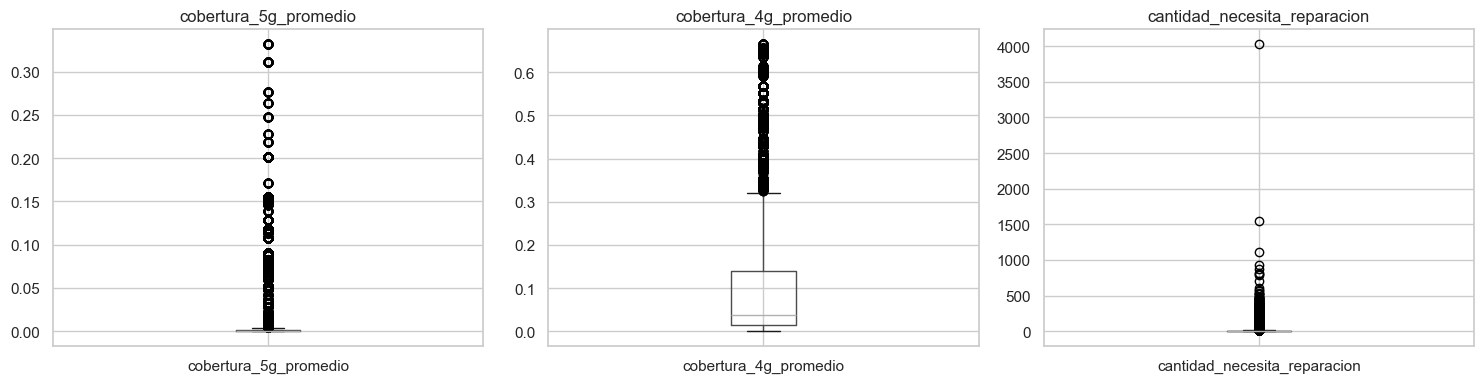

In [ ]:
import matplotlib.pyplot as plt

top_cols = pd.Series(resumen_outliers).sort_values(ascending=False).head(3).index.tolist()

fig, axes = plt.subplots(1, len(top_cols), figsize=(5 * len(top_cols), 4))
for ax, col in zip(axes, top_cols):
    base_final.boxplot(column=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [ ]:
# Caso 1: revisión de los valores de reparación que superan el umbral superior.
col = "cantidad_necesita_reparacion"
outliers, lim_sup = detectar_outliers_superior(base_final, col)
print(f"Límite superior: {lim_sup:.2f}")
print(f"Cantidad de outliers: {len(outliers)}")
display(outliers[["cod_local", col]].sort_values(col, ascending=False).head(10))


Límite superior: 12.50
Cantidad de outliers: 6934


,cod_local,cantidad_necesita_reparacion
13864,220064,4032
34351,649664,1542
28142,486742,1114
9073,149261,928
4758,082227,872
2710,047700,821
9582,157374,798
8154,133608,783
311,006511,704
15449,248553,602


In [ ]:
# Caso 2: revisión de ancho de banda con los dos límites del IQR.
col = "maximo_ancho_banda"
outliers, lim_inf, lim_sup = detectar_outliers_iqr(base_final, col)
print(f"Límites: [{lim_inf:.2f}, {lim_sup:.2f}]")
print(f"Cantidad de outliers: {len(outliers)}")
display(outliers[["cod_local", col]].sort_values(col, ascending=False).head(10))


Límites: [-375.00, 705.00]
Cantidad de outliers: 2032


,cod_local,maximo_ancho_banda
40587,840832,1024.0
41701,866737,1024.0
20343,332387,1024.0
19963,324797,1024.0
37569,749512,1024.0
19969,324863,1024.0
40751,844444,1024.0
19535,317320,1024.0
19829,322604,1024.0
42143,913423,1024.0


In [ ]:
display(base_final[base_final["cod_local"] == "220064"][
    ["cod_local", "cantidad_total_recursos", "cantidad_recur_operativo",
     "cantidad_buen_estado", "cantidad_necesita_reparacion"]
])

,cod_local,cantidad_total_recursos,cantidad_recur_operativo,cantidad_buen_estado,cantidad_necesita_reparacion
13864,220064,4032,4032,0,4032


In [ ]:
display(recursos_tecnologicos[recursos_tecnologicos["cod_local"] == "220064"])

,cod_local,num_orden,tipo_recurso,cant_total,cant_operativos,cant_buen_estado,cant_necesita_reparacion,cant_antig_menos_3anios,cant_antig_mas_3anios,fecha_envio
47596,220064,1,Computo,280,280,0,280,0,280,2025-09-20 11:16:45
47597,220064,2,Computo,79,79,0,79,0,79,2025-09-20 11:16:45
47598,220064,3,Computo,194,194,0,194,0,194,2025-09-20 11:16:45
47599,220064,6,Tablets_Moviles,2000,2000,0,2000,0,2000,2025-09-20 11:16:45
47600,220064,8,Tablets_Moviles,1392,1392,0,1392,0,1392,2025-09-20 11:16:45
47601,220064,9,Multimedia_Perifericos,77,77,0,77,0,77,2025-09-20 11:16:45
47602,220064,10,Multimedia_Perifericos,10,10,0,10,0,10,2025-09-20 11:16:45


In [ ]:
cols_recursos = ["cantidad_total_recursos", "cantidad_recur_operativo",
                  "cantidad_buen_estado", "cantidad_necesita_reparacion",
                  "numero_recursos_menos_3_años", "numero_recursos_mas_3_años"]
base_final.loc[base_final["cod_local"] == "220064", cols_recursos] = np.nan

In [ ]:
cols_dummy = ["Computo", "Infraestructura_TI", "Multimedia_Perifericos", "Tablets_Moviles"]
base_final.loc[base_final["cod_local"] == "220064", cols_dummy] = np.nan

In [ ]:
base_final["linea_activa"].value_counts()

linea_activa
0    21757
1    17953
2     1814
3      383
4      314
Name: count, dtype: int64

Se revisó el local `220064`, que registra 4 032 recursos operativos, todos necesitados de reparación y ninguno en buen estado. Sus siete registros incluyen 2 000 y 1 392 tablets. Como decisión de tratamiento de este caso, se sustituyen por `NaN` las seis cantidades y los cuatro indicadores de familias de recursos; el local permanece en la base.

Las cantidades cuadran entre sí, por lo que el patrón extremo no prueba por sí solo un error. Se deja constancia de que esta anulación es una decisión sobre un caso dudoso, no una corrección confirmada mediante otra fuente.


In [ ]:
# Verificación: comprobar que se aplicó la decisión de marcar sus recursos como faltantes.
display(base_final[base_final["cod_local"] == "220064"][
    ["cod_local", "cantidad_total_recursos", "cantidad_necesita_reparacion", "Computo", "Tablets_Moviles"]
])


,cod_local,cantidad_total_recursos,cantidad_necesita_reparacion,Computo,Tablets_Moviles
13864,220064,NaN,NaN,NaN,NaN


### Resumen de decisiones — Sección 9

Los conteos se calculan antes de marcar como faltantes los recursos del local `220064`. Un mismo local puede aparecer como atípico en varias variables.

| Variable o grupo | Atípicos detectados | Tratamiento aplicado |
|---|---:|---|
| `cobertura_5g_promedio` | 9 227 | Se conservan; superar el umbral no demuestra un error |
| `cantidad_necesita_reparacion` | 6 934 | Se anulan los campos de recursos del local 220064; los demás valores se conservan |
| `maximo_ancho_banda` | 2 032 | Se conservan los valores reportados; los mayores mostrados son 1 024 Mbps |
| Otras cantidades del Grupo 1 | 4 748–6 635 por variable | La misma anulación de recursos afecta al local 220064; no se eliminan los demás extremos |
| Velocidades | 2 201–2 714 por variable | Se conservan los valores reportados |
| `minimo_ancho_banda` | 2 341 | Se conserva sin cambios |
| `cobertura_4g_promedio` | 7 551 | Se conserva sin cambios |


### **Sección 10: Transformación de variables y construcción de la matriz analítica**

Después de la limpieza, integración de las fuentes y revisión de valores atípicos, se preparan las variables que posteriormente serán utilizadas para identificar perfiles de brecha tecnológica.

La técnica propuesta es **clustering**, ya que se busca agrupar locales educativos con características tecnológicas similares sin disponer de una variable objetivo previamente definida.

Para ello se realizan tres pasos:

1. Crear variables que permitan comparar locales de diferente tamaño.
2. Seleccionar las variables que realmente representan la brecha tecnológica.
3. Reescalar únicamente las variables cuantitativas que utilizan escalas diferentes.


#### **Transformación de variables**

Se crea una copia de `base_final` para conservar intacta la base integrada original.

Las variables que indican presencia de Internet se transforman de "Sí/No" a valores numéricos:

- Sí = 1
- No = 0

Los valores desconocidos permanecen como faltantes y no se interpretan como ausencia de Internet.

In [ ]:
base_modelo = base_final.copy()

# Sí = 1, No = 0
base_modelo["local_educativo_tiene_internet"] = (
    base_modelo["local_educativo_tiene_internet"]
    .map({"Sí": 1, "No": 0})
)

base_modelo["centro_poblado_tiene_internet"] = (
    base_modelo["centro_poblado_tiene_internet"]
    .map({"Sí": 1, "No": 0})
)

#### **Creación de variables derivadas**

Además de la cantidad total, se calculan tres proporciones sobre el inventario del local:

- `prop_operativos`: recursos operativos divididos entre el total.
- `prop_reparacion`: recursos que necesitan reparación divididos entre el total. En esta fuente forman parte de los operativos.
- `prop_antiguos`: recursos operativos con más de tres años divididos entre el total. No describe la antigüedad de los recursos no operativos.

Estas proporciones comparan la composición del inventario; no miden si la cantidad de equipos es suficiente para el número de estudiantes.


In [ ]:
total = base_modelo["cantidad_total_recursos"]

base_modelo["prop_operativos"] = (
    base_modelo["cantidad_recur_operativo"] / total
)

base_modelo["prop_reparacion"] = (
    base_modelo["cantidad_necesita_reparacion"] / total
)

base_modelo["prop_antiguos"] = (
    base_modelo["numero_recursos_mas_3_años"] / total
)

#### **Selección de variables para la matriz analítica**

La matriz analítica contiene únicamente las variables que deben intervenir en la formación de los perfiles tecnológicos.

Se consideran cinco dimensiones:

- disponibilidad de recursos;
- estado y antigüedad;
- tipos de recursos;
- conectividad del local;
- cobertura móvil territorial.

No se incorporan identificadores, nombres geográficos, latitud ni longitud porque sirven para localizar e interpretar posteriormente los resultados, pero no deben determinar la formación de los grupos.

Tampoco se utilizan las variables de velocidad y ancho de banda debido a la elevada cantidad de datos faltantes encontrada previamente.


In [ ]:
columnas_analiticas = [
    # Disponibilidad
    "cantidad_total_recursos",

    # Estado de los recursos
    "prop_operativos",
    "prop_reparacion",
    "prop_antiguos",

    # Tipos de recursos
    "Computo",
    "Infraestructura_TI",
    "Multimedia_Perifericos",
    "Tablets_Moviles",

    # Conectividad
    "local_educativo_tiene_internet",
    "centro_poblado_tiene_internet",
    "cantidad_lineas_internet",

    # Cobertura 4G
    "cobertura_4g_promedio",
    "mejor_cobertura_4g",
    "proporcion_ccpp_4g",

    # Cobertura 5G
    "cobertura_5g_promedio",
    "mejor_cobertura_5g",
    "proporcion_ccpp_5g"
]

matriz_analitica = base_modelo[columnas_analiticas].copy()

print("Dimensiones:", matriz_analitica.shape)
matriz_analitica.head()

Dimensiones: (42221, 17)


,cantidad_total_recursos,prop_operativos,prop_reparacion,prop_antiguos,Computo,Infraestructura_TI,Multimedia_Perifericos,Tablets_Moviles,local_educativo_tiene_internet,centro_poblado_tiene_internet,cantidad_lineas_internet,cobertura_4g_promedio,mejor_cobertura_4g,proporcion_ccpp_4g,cobertura_5g_promedio,mejor_cobertura_5g,proporcion_ccpp_5g
0,4.0,1.0,0.0,0.500000,1.0,0.0,1.0,0.0,1,1,1,0.042986,0.150082,0.2,0.002929,0.011714,0.028571
1,6.0,1.0,0.0,1.000000,1.0,0.0,1.0,0.0,1,1,1,0.042986,0.150082,0.2,0.002929,0.011714,0.028571
2,1.0,1.0,0.0,1.000000,0.0,0.0,1.0,0.0,0,0,0,0.042986,0.150082,0.2,0.002929,0.011714,0.028571
3,2.0,1.0,0.5,1.000000,1.0,0.0,1.0,0.0,1,0,0,0.042986,0.150082,0.2,0.002929,0.011714,0.028571
4,41.0,1.0,0.0,0.487805,1.0,0.0,1.0,1.0,1,1,1,0.042986,0.150082,0.2,0.002929,0.011714,0.028571


#### **Revisión de valores faltantes**

La matriz tiene 42 221 filas y 17 variables. Se identifican seis filas con al menos un faltante: el local cuyos recursos se anularon y cinco locales sin cobertura distrital. En este bloque no se realiza una nueva imputación ni se eliminan esas filas. Se conservan también en la matriz escalada, por lo que su tratamiento queda pendiente antes de aplicar un método que requiera datos completos.


In [ ]:
faltantes = matriz_analitica.isna().sum()

display(
    faltantes[faltantes > 0]
    .to_frame("faltantes")
)

print(
    "Filas con al menos un faltante:",
    matriz_analitica.isna().any(axis=1).sum()
)

,faltantes
cantidad_total_recursos,1
prop_operativos,1
prop_reparacion,1
prop_antiguos,1
Computo,1
Infraestructura_TI,1
Multimedia_Perifericos,1
Tablets_Moviles,1
cobertura_4g_promedio,5
mejor_cobertura_4g,5


Filas con al menos un faltante: 6


#### **Reescalamiento de variables**

Las variables cuantitativas utilizan escalas diferentes. Por ejemplo, la cantidad de recursos puede tomar valores mucho mayores que las proporciones o las variables de cobertura.

Como el clustering puede utilizar distancias para determinar qué observaciones son similares, estas diferencias de escala pueden hacer que algunas variables tengan una influencia mayor únicamente por su magnitud.

Por ello se aplica normalización **Min-Max** para las variables cuantitativas.

Las variables binarias no se reescalan, ya que su escala original 0/1 tiene una interpretación directa:

- 0 = ausencia registrada
- 1 = presencia registrada


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Variables binarias que ya están en escala 0/1
columnas_binarias = [
    "Computo",
    "Infraestructura_TI",
    "Multimedia_Perifericos",
    "Tablets_Moviles",
    "local_educativo_tiene_internet",
    "centro_poblado_tiene_internet"
]

# Variables cuantitativas que sí se reescalarán
columnas_reescalar = [
    col for col in matriz_analitica.columns
    if col not in columnas_binarias
]

# Copia de la matriz
matriz_escalada = matriz_analitica.copy()

# Aplicar Min-Max solamente a variables cuantitativas
scaler = MinMaxScaler()

matriz_escalada[columnas_reescalar] = scaler.fit_transform(
    matriz_analitica[columnas_reescalar]
)

matriz_escalada.head()

,cantidad_total_recursos,prop_operativos,prop_reparacion,prop_antiguos,Computo,Infraestructura_TI,Multimedia_Perifericos,Tablets_Moviles,local_educativo_tiene_internet,centro_poblado_tiene_internet,cantidad_lineas_internet,cobertura_4g_promedio,mejor_cobertura_4g,proporcion_ccpp_4g,cobertura_5g_promedio,mejor_cobertura_5g,proporcion_ccpp_5g
0,0.0003,1.0,0.0,0.500000,1.0,0.0,1.0,0.0,1,1,0.25,0.064538,0.150082,0.2,0.008819,0.013426,0.028571
1,0.0005,1.0,0.0,1.000000,1.0,0.0,1.0,0.0,1,1,0.25,0.064538,0.150082,0.2,0.008819,0.013426,0.028571
2,0.0000,1.0,0.0,1.000000,0.0,0.0,1.0,0.0,0,0,0.00,0.064538,0.150082,0.2,0.008819,0.013426,0.028571
3,0.0001,1.0,0.5,1.000000,1.0,0.0,1.0,0.0,1,0,0.00,0.064538,0.150082,0.2,0.008819,0.013426,0.028571
4,0.0040,1.0,0.0,0.487805,1.0,0.0,1.0,1.0,1,1,0.25,0.064538,0.150082,0.2,0.008819,0.013426,0.028571


## **Fase 5: Visualización y hallazgos**

### **1. Equipamiento según diversidad del financiamiento de internet**

**Pregunta de análisis:** ¿Cómo se distribuye la cantidad de recursos operativos entre los locales que registran una, dos o tres categorías de financiamiento de internet?

Las filas representan el número de categorías de financiamiento, no líneas ni entidades individuales. Hay 20 462 locales con alguna de las tres categorías identificada. El gráfico utiliza 20 461 con recursos válidos: 19 776 con una categoría, 667 con dos y 18 con tres. Un local con una categoría queda fuera del cálculo porque sus recursos se marcaron como faltantes. Cada fila suma aproximadamente 100 %. Los intervalos describen cantidades y no estándares de suficiencia.


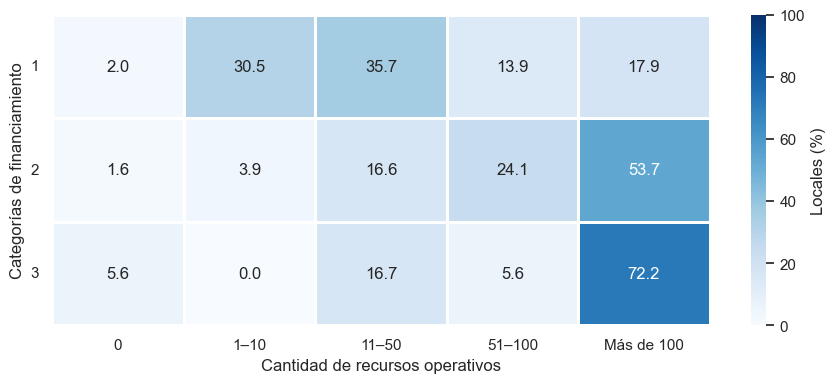

In [ ]:
# 1. Contar las categorías de financiamiento de cada local
financiamiento = base_final[
    ["financiamiento de _Público",
     "financiamiento de _Privado / Otro",
     "financiamiento de _Comunidad / IE"]
].apply(pd.to_numeric).sum(axis=1, min_count=3)

# 2. Agrupar los locales según sus recursos operativos
recursos = pd.cut(
    pd.to_numeric(base_final["cantidad_recur_operativo"]),
    bins=[-1, 0, 10, 50, 100, float("inf")],
    labels=["0", "1–10", "11–50", "51–100", "Más de 100"]
)

# 3. Calcular porcentajes dentro de cada grupo y graficar
tabla = pd.crosstab(
    financiamiento, recursos, normalize="index"
).reindex([1, 2, 3]) * 100

plt.figure(figsize=(9, 4))

sns.heatmap(
    tabla,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100,
    linewidths=1,
    cbar_kws={"label": "Locales (%)"}
)

plt.xlabel("Cantidad de recursos operativos")
plt.ylabel("Categorías de financiamiento")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretación.** Los locales con más categorías de financiamiento de internet tienden a tener mayor equipamiento. El 17,9 % de los que tienen una categoría supera los 100 recursos operativos, frente al 53,7 % de los que tienen dos. Con tres categorías llega al 72,2 %, pero son solo 13 de 18 locales, así que ese resultado debe tomarse con cuidado. Esto muestra una asociación; no significa que esas fuentes hayan financiado los equipos.


### **2. Velocidad de bajada según financiamiento: locales con una sola línea**

**Pregunta de análisis:** ¿Cómo se distribuye la velocidad de bajada reportada según el financiamiento, entre locales con una única línea registrada, activa y con velocidad positiva?

Este filtro permite relacionar la velocidad y el financiamiento de la misma línea. El gráfico incluye 17 297 locales con categoría identificada: 7 576 en Público, 2 547 en Privado / Otro y 7 174 en Comunidad / IE. Se excluyen velocidades cero o faltantes y un caso con velocidad positiva sin financiamiento identificado. Los resultados se interpretan para este subconjunto.



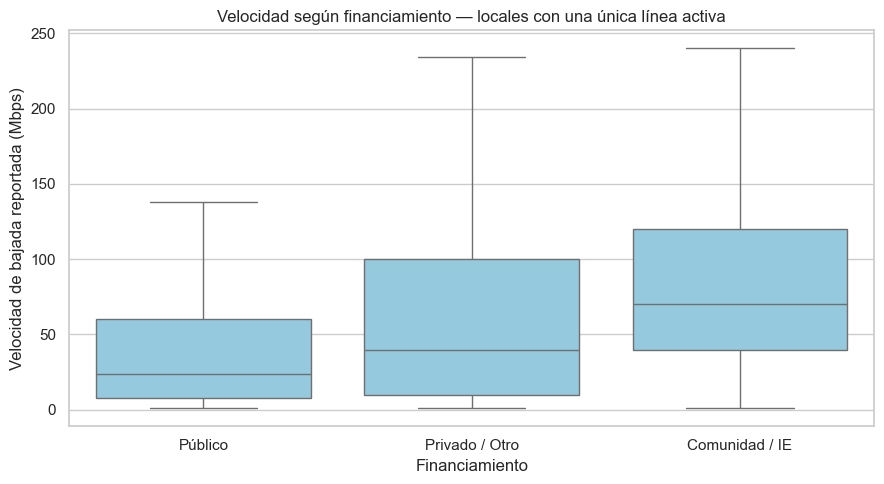

In [ ]:
datos = base_final.query(
    "num_linea == 1 and linea_activa == 1 "
    "and max_velocidad_bajada > 0"
).copy()

fuentes = {
    "financiamiento de _Público": "Público",
    "financiamiento de _Privado / Otro": "Privado / Otro",
    "financiamiento de _Comunidad / IE": "Comunidad / IE"
}

datos["Financiamiento"] = None

for columna, nombre in fuentes.items():
    datos.loc[datos[columna] == 1, "Financiamiento"] = nombre

sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=datos,
    x="Financiamiento",
    y="max_velocidad_bajada",
    order=["Público", "Privado / Otro", "Comunidad / IE"],
    showfliers=False,
    color="skyblue"
)

plt.title("Velocidad según financiamiento — locales con una única línea activa")
plt.xlabel("Financiamiento")
plt.ylabel("Velocidad de bajada reportada (Mbps)")
plt.tight_layout()
plt.show()

**Interpretación.** Entre los locales con una sola línea activa y velocidad positiva, Comunidad / IE tiene la mayor velocidad mediana: 70 Mbps, frente a 40 en Privado / Otro y 24 en Público. Las cajas se superponen, por lo que también hay velocidades similares entre categorías. La diferencia no se puede atribuir solo al financiamiento, ya que los locales tienen otras características distintas. Los puntos extremos están ocultos, pero siguen incluidos en el cálculo.

### **3. Tipos de recursos según acceso a internet**

**Pregunta de análisis:** ¿Los locales con y sin internet presentan la misma composición de equipamiento tecnológico?

La base contiene 42 221 locales: 20 787 con internet y 21 434 sin internet. El cálculo utiliza los 42 220 con indicadores de recursos válidos: 20 786 con internet y 21 434 sin internet. Un local conectado se omite al tener esos campos faltantes. Cada celda muestra el porcentaje de locales de su grupo que registra esa familia. Las filas no tienen que sumar 100 %, porque un local puede registrar varias.


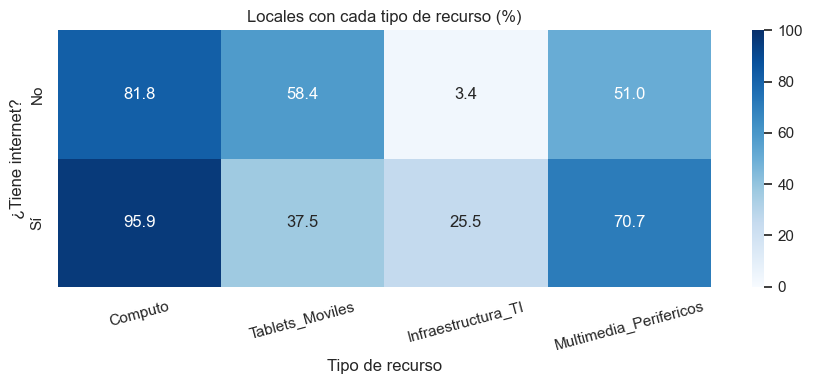

In [ ]:
plt.figure(figsize=(9, 4))

sns.heatmap(
    base_final.groupby("local_educativo_tiene_internet")[
        ["Computo", "Tablets_Moviles",
         "Infraestructura_TI", "Multimedia_Perifericos"]
    ].mean() * 100,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100
)

plt.title("Locales con cada tipo de recurso (%)")
plt.xlabel("Tipo de recurso")
plt.ylabel("¿Tiene internet?")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Interpretación.** Los locales con internet tienen mayor presencia de cómputo, infraestructura TI y multimedia. En infraestructura TI, la diferencia es de 25,5 % frente a 3,4 %. Lo que más llama la atención son las tablets: aparecen en 58,4 % de los locales sin internet y en 37,5 % de los conectados. Esto muestra perfiles de equipamiento distintos, aunque registrar un tipo de recurso no indica cuántos equipos hay ni si funcionan o se utilizan.

### **4. Estado del equipamiento según acceso a internet**

**Pregunta de análisis:** ¿Cómo cambia el estado del equipamiento entre locales conectados y no conectados?

Primero se calcula el porcentaje de recursos en buen estado, que necesita reparación y que no está operativo en cada local. Después se promedian esos porcentajes por acceso a internet. Cada local tiene el mismo peso, sin importar el tamaño de su inventario. Se utilizan 42 220 locales con cantidades válidas y total mayor que cero; el local con recursos marcados como faltantes no entra en los promedios.


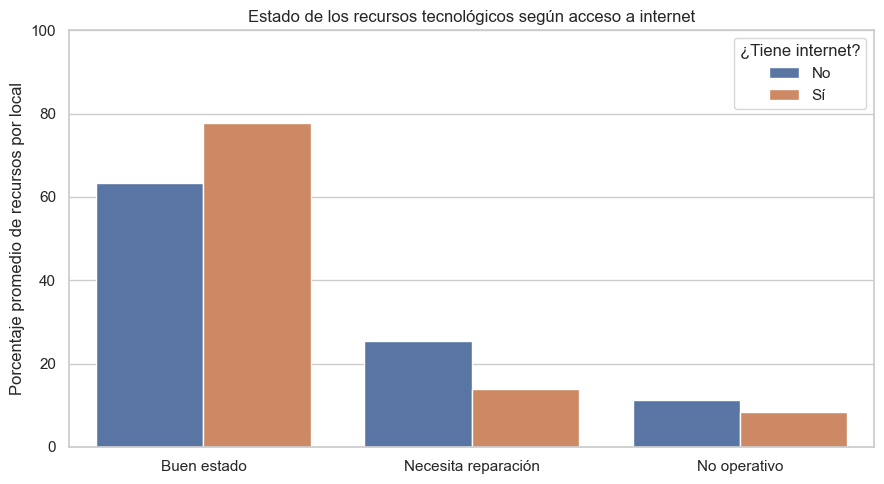

In [ ]:
tabla_estado = pd.DataFrame({
    "Buen estado": base_final["cantidad_buen_estado"],
    "Necesita reparación": base_final["cantidad_necesita_reparacion"],
    "No operativo": (
        base_final["cantidad_total_recursos"]
        - base_final["cantidad_recur_operativo"]
    )
}).div(base_final["cantidad_total_recursos"], axis=0) * 100

tabla_estado["Internet"] = base_final["local_educativo_tiene_internet"]
tabla_estado = tabla_estado.groupby("Internet").mean().reset_index().melt(
    id_vars="Internet", var_name="Estado", value_name="Porcentaje"
)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))
sns.barplot(data=tabla_estado,x="Estado",y="Porcentaje",hue="Internet",)

plt.title("Estado de los recursos tecnológicos según acceso a internet")
plt.xlabel("")
plt.ylabel("Porcentaje promedio de recursos por local")
plt.ylim(0, 100)
plt.legend(title="¿Tiene internet?")
plt.tight_layout()
plt.show()

**Interpretación.** Los locales sin internet presentan una menor proporción promedio de recursos en buen estado: 63,4 %, frente a 77,9 % entre los conectados. Además, la proporción que necesita reparación es mayor: 25,4 % frente a 13,8 %. La diferencia en recursos no operativos es más pequeña. Así, la falta de conexión coincide con condiciones de conservación menos favorables, sin que podamos afirmar que una cause la otra. En esta base, un recurso puede estar operativo y necesitar reparación.

### **5. Cobertura 4G distrital y conexión del local educativo**

**Pregunta de análisis:** ¿Los locales ubicados en distritos con una mayor proporción de centros poblados con alguna cobertura 4G reportan internet con mayor frecuencia?

`proporcion_ccpp_4g` es un dato del distrito incorporado a cada local. En la integración, un centro poblado cuenta como cubierto cuando al menos un operador registra cobertura 4G mayor que cero. El indicador no representa porcentaje de territorio ni de población cubierta. El gráfico incluye 42 216 locales; cinco no tienen información de este indicador. Cada fila suma aproximadamente 100 % de los locales de su grupo.

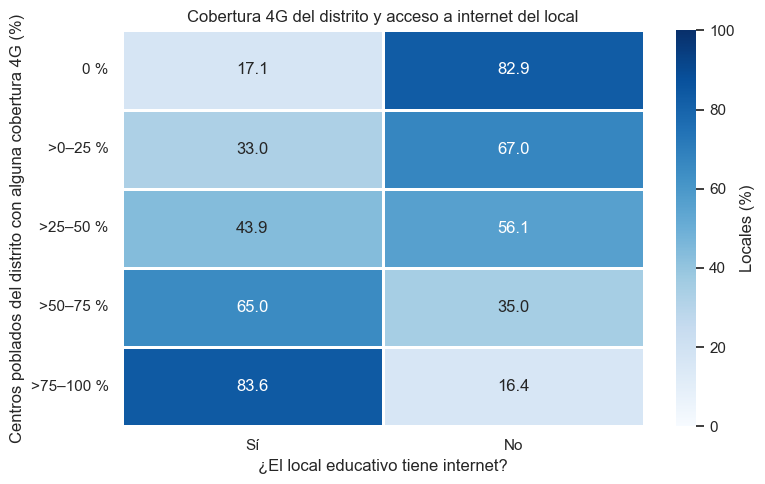

In [ ]:
# Agrupar según la cobertura 4G del distrito
cobertura = pd.cut(
    base_final["proporcion_ccpp_4g"],
    bins=[-0.001, 0, 0.25, 0.50, 0.75, 1],
    labels=["0 %", ">0–25 %", ">25–50 %", ">50–75 %", ">75–100 %"]
)

# Porcentaje de locales con y sin internet dentro de cada grupo
tabla = pd.crosstab(
    cobertura,
    base_final["local_educativo_tiene_internet"],
    normalize="index"
).reindex(columns=["Sí", "No"]) * 100

plt.figure(figsize=(8, 5))

sns.heatmap(
    tabla,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100,
    linewidths=1,
    cbar_kws={"label": "Locales (%)"}
)

plt.title("Cobertura 4G del distrito y acceso a internet del local")
plt.xlabel("¿El local educativo tiene internet?")
plt.ylabel("Centros poblados del distrito con alguna cobertura 4G (%)")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretación.** La proporción de locales con internet aumenta entre los grupos con mayor cobertura 4G en los centros poblados de su distrito: pasa de 17,1 % en el primer grupo a 83,6 % en el último. Aun así, en este último grupo un 16,4 % no tiene internet. Esto muestra que la cobertura del entorno y la conexión del local no siempre coinciden. El dato es distrital: no permite asegurar que haya señal en la ubicación exacta del colegio.